# Visualize exchange experiment DE results

This notebook reads the exported limma DE tables for GCM1, NKX2-1, ISL1, and EOMES from `personal_path/publication`, then summarizes and plots all available institution-level results, including NW parent/DMSO variants.

In [16]:
suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(ggplot2)
  library(ggrepel)
  library(stringr)
  library(tidyr)
  library(purrr)
  library(tibble)
})

theme_set(theme_classic(base_size = 12))

set_notebook_plot_size <- function(width = 14, height = 9, res = 140, pointsize = 12) {
  options(
    repr.plot.width = width,
    repr.plot.height = height,
    repr.plot.res = res,
    repr.plot.pointsize = pointsize
  )
  invisible(NULL)
}

set_notebook_plot_size()

target_genes <- c("GCM1", "NKX2-1", "ISL1", "EOMES")
core_institutions <- c("JAX", "MSK", "UCSF", "NW")
cohort_order <- c(core_institutions, "NW_parent", "NW_DMSO")

fdr_cutoff <- 0.05
logfc_cutoff <- 1
print_each_volcano <- TRUE

personal_path <- Sys.getenv("MORPHIC_PERSONAL_PATH", unset = "/fh/working/sun_w/sshen/MorPhiC")
publication_dir <- file.path(personal_path, "publication")
figure_dir <- file.path(publication_dir, "DE_summary_ipynb")
volcano_figure_dir <- file.path(figure_dir, "volcano_plots")

stopifnot(dir.exists(publication_dir))
dir.create(volcano_figure_dir, recursive = TRUE, showWarnings = FALSE)

publication_dir
figure_dir

[1] "/fh/working/sun_w/sshen/MorPhiC/publication"

[1] "/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb"

## Discover DE result files

In [17]:
de_file_paths <- list.files(
  publication_dir,
  pattern = "_DE_.*[.]csv$",
  full.names = TRUE
)

de_file_index <- tibble(file = de_file_paths) %>%
  mutate(
    file_name = basename(file),
    stem = tools::file_path_sans_ext(file_name),
    target_gene = sub("_DE_.*$", "", stem),
    cohort = sub("^.*_DE_", "", stem),
    dataset_id = paste(target_gene, cohort, sep = "_DE_")
  ) %>%
  filter(target_gene %in% target_genes) %>%
  arrange(
    factor(target_gene, levels = target_genes),
    factor(cohort, levels = cohort_order),
    cohort
  )

expected_core <- tidyr::expand_grid(
  target_gene = target_genes,
  cohort = core_institutions
)

missing_core <- anti_join(
  expected_core,
  de_file_index %>% distinct(target_gene, cohort),
  by = c("target_gene", "cohort")
)

de_file_index %>% select(target_gene, cohort, file_name)
missing_core

target_gene,cohort,file_name
<chr>,<chr>,<chr>
GCM1,JAX,GCM1_DE_JAX.csv
GCM1,MSK,GCM1_DE_MSK.csv
GCM1,UCSF,GCM1_DE_UCSF.csv
GCM1,NW,GCM1_DE_NW.csv
GCM1,NW_parent,GCM1_DE_NW_parent.csv
NKX2-1,JAX,NKX2-1_DE_JAX.csv
NKX2-1,MSK,NKX2-1_DE_MSK.csv
NKX2-1,UCSF,NKX2-1_DE_UCSF.csv
NKX2-1,NW,NKX2-1_DE_NW.csv


target_gene,cohort
<chr>,<chr>


## Read and combine DE tables

In [18]:
read_de_table <- function(file, target_gene, cohort) {
  dt <- data.table::fread(file, data.table = FALSE)
  expected_cols <- c("logFC", "AveExpr", "t", "P.Value", "adj.P.Val", "B")
  
  if (!"gene_symbol" %in% names(dt)) {
    if ("V1" %in% names(dt)) {
      names(dt)[names(dt) == "V1"] <- "gene_symbol"
    } else if (ncol(dt) == length(expected_cols) + 1 && !(names(dt)[1] %in% expected_cols)) {
      names(dt)[1] <- "gene_symbol"
    } else {
      stop("Could not identify gene symbol column in ", file)
    }
  }
  
  missing_cols <- setdiff(c("gene_symbol", expected_cols), names(dt))
  if (length(missing_cols) > 0) {
    stop("Missing columns in ", file, ": ", paste(missing_cols, collapse = ", "))
  }
  
  dt %>%
    transmute(
      target_gene = target_gene,
      cohort = cohort,
      dataset_id = paste(target_gene, cohort, sep = "_DE_"),
      gene_symbol = as.character(gene_symbol),
      logFC = as.numeric(logFC),
      AveExpr = as.numeric(AveExpr),
      t = as.numeric(t),
      P.Value = as.numeric(P.Value),
      adj.P.Val = as.numeric(adj.P.Val),
      B = as.numeric(B),
      neg_log10_adj_p = -log10(pmax(adj.P.Val, .Machine$double.xmin)),
      is_significant = adj.P.Val < fdr_cutoff & abs(logFC) >= logfc_cutoff,
      direction = case_when(
        is_significant & logFC > 0 ~ "up",
        is_significant & logFC < 0 ~ "down",
        TRUE ~ "not_sig"
      ),
      source_file = basename(file)
    )
}

de_results <- pmap_dfr(
  de_file_index %>% select(file, target_gene, cohort),
  read_de_table
) %>%
  mutate(
    target_gene = factor(target_gene, levels = target_genes),
    cohort = factor(cohort, levels = unique(c(cohort_order, sort(unique(as.character(cohort))))), ordered = TRUE),
    direction = factor(direction, levels = c("down", "not_sig", "up"))
  )

dim(de_results)
de_results %>% count(target_gene, cohort)

Warning message in data.table::fread(file, data.table = FALSE):
“Detected 6 column names but the data has 7 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”


Warning message in data.table::fread(file, data.table = FALSE):
“Detected 6 column names but the data has 7 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in data.table::fread(file, data.table = FALSE):
“Detected 6 column names but the data has 7 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in data.table::fread(file, data.table = FALSE):
“Detected 6 column names but the data has 7 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() af

[1] 472471     14

target_gene,cohort,n
<fct>,<ord>,<int>
GCM1,JAX,21366
GCM1,MSK,21366
GCM1,UCSF,21644
GCM1,NW,21644
GCM1,NW_parent,21435
NKX2-1,JAX,22730
NKX2-1,MSK,22655
NKX2-1,UCSF,22866
NKX2-1,NW,22842


## Check selected genes in DE results

In [19]:
genes_to_check <- tibble::tribble(
  ~target_gene, ~query_gene, ~canonical_gene,
  "EOMES", "SOX17", "SOX17",
  "GCM1", "PGF", "PGF",
  "GCM1", "pRR9", "PRR9",
  "GCM1", "TWIST2", "TWIST2",
  "GCM1", "LMO2", "LMO2"
) %>%
  mutate(
    target_gene = as.character(target_gene),
    gene_key = str_to_upper(canonical_gene)
  )

selected_gene_de <- de_results %>%
  mutate(
    target_gene = as.character(target_gene),
    cohort = as.character(cohort),
    gene_key = str_to_upper(gene_symbol)
  ) %>%
  inner_join(genes_to_check, by = c("target_gene", "gene_key")) %>%
  mutate(
    is_DE = adj.P.Val < fdr_cutoff & abs(logFC) >= logfc_cutoff,
    DE_direction = case_when(
      is_DE & logFC > 0 ~ "up",
      is_DE & logFC < 0 ~ "down",
      TRUE ~ "not_DE"
    )
  ) %>%
  select(
    target_gene,
    query_gene,
    canonical_gene,
    matched_gene_symbol = gene_symbol,
    cohort,
    logFC,
    adj.P.Val,
    is_DE,
    DE_direction,
    AveExpr,
    P.Value,
    t,
    B,
    source_file
  ) %>%
  arrange(
    factor(target_gene, levels = target_genes),
    factor(canonical_gene, levels = genes_to_check$canonical_gene),
    factor(cohort, levels = unique(c(cohort_order, sort(unique(cohort)))) )
  )

target_gene_cohorts <- de_results %>%
  mutate(target_gene = as.character(target_gene), cohort = as.character(cohort)) %>%
  distinct(target_gene, cohort)

selected_gene_presence <- genes_to_check %>%
  select(target_gene, query_gene, canonical_gene, gene_key) %>%
  inner_join(target_gene_cohorts, by = "target_gene", relationship = "many-to-many") %>%
  left_join(
    selected_gene_de,
    by = c("target_gene", "query_gene", "canonical_gene", "cohort")
  ) %>%
  mutate(
    tested_in_DE_table = !is.na(matched_gene_symbol),
    is_DE = if_else(is.na(is_DE), FALSE, is_DE),
    DE_direction = if_else(is.na(DE_direction), "not_tested", DE_direction)
  ) %>%
  select(
    target_gene,
    query_gene,
    canonical_gene,
    cohort,
    tested_in_DE_table,
    matched_gene_symbol,
    logFC,
    adj.P.Val,
    is_DE,
    DE_direction,
    everything(),
    -gene_key
  ) %>%
  arrange(
    factor(target_gene, levels = target_genes),
    factor(canonical_gene, levels = genes_to_check$canonical_gene),
    factor(cohort, levels = unique(c(cohort_order, sort(unique(cohort)))) )
  )

selected_gene_summary <- selected_gene_presence %>%
  group_by(target_gene, query_gene, canonical_gene) %>%
  summarise(
    tested_cohorts = paste(cohort[tested_in_DE_table], collapse = ", "),
    DE_cohorts = paste(cohort[is_DE], collapse = ", "),
    up_cohorts = paste(cohort[DE_direction == "up"], collapse = ", "),
    down_cohorts = paste(cohort[DE_direction == "down"], collapse = ", "),
    .groups = "drop"
  ) %>%
  mutate(
    DE_cohorts = if_else(DE_cohorts == "", "none", DE_cohorts),
    up_cohorts = if_else(up_cohorts == "", "none", up_cohorts),
    down_cohorts = if_else(down_cohorts == "", "none", down_cohorts)
  )

selected_gene_presence
selected_gene_summary

selected_gene_output_file <- file.path(figure_dir, "selected_gene_DE_check.tsv")
data.table::fwrite(selected_gene_presence, selected_gene_output_file, sep = "\t")
selected_gene_output_file


target_gene,query_gene,canonical_gene,cohort,tested_in_DE_table,matched_gene_symbol,logFC,adj.P.Val,is_DE,DE_direction,AveExpr,P.Value,t,B,source_file
<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<dbl>,<dbl>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
GCM1,PGF,PGF,JAX,TRUE,PGF,-4.27130187,1.631506e-13,TRUE,down,8.776465,3.054396e-16,-44.242584,27.7395326,GCM1_DE_JAX.csv
GCM1,PGF,PGF,MSK,TRUE,PGF,-4.27503616,1.246123e-10,TRUE,down,8.787382,5.142306e-13,-28.134523,20.3402361,GCM1_DE_MSK.csv
GCM1,PGF,PGF,UCSF,TRUE,PGF,-3.90771770,1.515016e-30,TRUE,down,9.624049,2.799882e-34,-118.765242,68.7274295,GCM1_DE_UCSF.csv
GCM1,PGF,PGF,NW,TRUE,PGF,-2.31009963,2.075936e-05,TRUE,down,9.647775,1.367698e-06,-7.475272,5.2855323,GCM1_DE_NW.csv
GCM1,PGF,PGF,NW_parent,TRUE,PGF,-3.11361780,5.768694e-07,TRUE,down,9.996553,4.247917e-08,-9.872366,8.3869043,GCM1_DE_NW_parent.csv
GCM1,pRR9,PRR9,JAX,TRUE,PRR9,-7.28208009,7.757280e-15,TRUE,down,4.584633,1.607167e-18,-64.881231,31.6305390,GCM1_DE_JAX.csv
GCM1,pRR9,PRR9,MSK,TRUE,PRR9,-8.00607869,2.106626e-12,TRUE,down,4.130369,5.915828e-16,-47.630992,25.9539543,GCM1_DE_MSK.csv
GCM1,pRR9,PRR9,UCSF,TRUE,PRR9,-4.64500613,1.186899e-29,TRUE,down,6.737155,7.677223e-33,-103.187346,65.1846274,GCM1_DE_UCSF.csv
GCM1,pRR9,PRR9,NW,TRUE,PRR9,-3.65570825,6.053633e-05,TRUE,down,7.118347,5.526695e-06,-6.671046,3.8897566,GCM1_DE_NW.csv


target_gene,query_gene,canonical_gene,tested_cohorts,DE_cohorts,up_cohorts,down_cohorts
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
EOMES,SOX17,SOX17,"JAX, MSK, UCSF, NW, NW_parent","JAX, MSK, NW, NW_parent",none,"JAX, MSK, NW, NW_parent"
GCM1,LMO2,LMO2,"UCSF, NW, NW_parent","UCSF, NW, NW_parent",none,"UCSF, NW, NW_parent"
GCM1,PGF,PGF,"JAX, MSK, UCSF, NW, NW_parent","JAX, MSK, UCSF, NW, NW_parent",none,"JAX, MSK, UCSF, NW, NW_parent"
GCM1,TWIST2,TWIST2,"JAX, MSK, UCSF, NW, NW_parent","JAX, MSK, UCSF, NW, NW_parent",none,"JAX, MSK, UCSF, NW, NW_parent"
GCM1,pRR9,PRR9,"JAX, MSK, UCSF, NW, NW_parent","JAX, MSK, UCSF, NW, NW_parent",none,"JAX, MSK, UCSF, NW, NW_parent"


[1] "/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/selected_gene_DE_check.tsv"

## Run permutation-free rank-based gene-set enrichment

Use a pre-ranked, no-permutation gene-set test on the exported limma statistics. This keeps the analysis self-contained in the DE result tables and avoids phenotype-label permutations that are brittle for small or dependent sample designs.


In [20]:
suppressPackageStartupMessages({
  library(limma)
  library(msigdbr)
})

annotation_file <- "/fh/fast/sun_w/sshen/MorPhiC/gencode_v44_primary_assembly_info.tsv"
stopifnot(file.exists(annotation_file))

make_unique_dash <- function(x) {
  ord <- seq_along(x)
  idx_within <- ave(ord, x, FUN = seq_along)
  dup_group <- duplicated(x) | duplicated(x, fromLast = TRUE)
  x_out <- x
  x_out[dup_group] <- paste0(x[dup_group], "-", idx_within[dup_group])
  x_out
}

pretty_gene_set_name <- function(x) {
  x %>%
    str_replace("^GOBP_", "") %>%
    str_replace("^REACTOME_", "") %>%
    str_replace_all("_", " ") %>%
    str_squish() %>%
    str_to_sentence()
}

gene_anno <- data.table::fread(annotation_file, data.table = FALSE) %>%
  mutate(
    hgnc_symbol = if_else(is.na(hgnc_symbol) | hgnc_symbol == "", ensembl_gene_id, hgnc_symbol),
    hgnc_symbol_unique = make_unique_dash(hgnc_symbol),
    gene_length = pmax(as.numeric(end) - as.numeric(start) + 1, 1)
  )

symbol_map <- bind_rows(
  gene_anno %>% transmute(gene_symbol = hgnc_symbol_unique, ensembl_gene_id, gene_length, map_priority = 1L),
  gene_anno %>% transmute(gene_symbol = hgnc_symbol, ensembl_gene_id, gene_length, map_priority = 2L),
  gene_anno %>% transmute(gene_symbol = ensembl_gene_id, ensembl_gene_id, gene_length, map_priority = 3L)
) %>%
  filter(!is.na(gene_symbol), gene_symbol != "", !is.na(ensembl_gene_id), !is.na(gene_length)) %>%
  arrange(map_priority) %>%
  distinct(gene_symbol, .keep_all = TRUE) %>%
  select(-map_priority)

# Make the join idempotent so this cell can be rerun without creating .x/.y columns.
de_results <- de_results %>%
  select(-any_of(c("ensembl_gene_id", "gene_length"))) %>%
  left_join(symbol_map, by = "gene_symbol")

unmapped_genes <- de_results %>%
  filter(is.na(ensembl_gene_id)) %>%
  distinct(gene_symbol) %>%
  arrange(gene_symbol)

cat("Mapped", sum(!is.na(de_results$ensembl_gene_id)), "of", nrow(de_results), "DE rows to Ensembl IDs.
")
cat("Unmapped unique gene symbols:", nrow(unmapped_genes), "
")
head(unmapped_genes, 20)

load_msigdb_gene_sets <- function(collection, subcollection, type_label) {
  msig_args <- names(formals(msigdbr::msigdbr))
  if (all(c("collection", "subcollection") %in% msig_args)) {
    msig <- msigdbr::msigdbr(
      species = "Homo sapiens",
      collection = collection,
      subcollection = subcollection
    )
  } else {
    legacy_subcollection <- if (collection == "C5") str_replace(subcollection, "^GO:", "") else subcollection
    msig <- msigdbr::msigdbr(
      species = "Homo sapiens",
      category = collection,
      subcategory = legacy_subcollection
    )
  }
  
  ensembl_col <- intersect(c("ensembl_gene", "ensembl_gene_id", "db_ensembl_gene"), names(msig))[1]
  if (is.na(ensembl_col)) {
    stop("Could not find an Ensembl gene column in msigdbr output for ", collection, ":", subcollection)
  }
  
  msig %>%
    transmute(
      gene = str_replace(.data[[ensembl_col]], "[.][0-9]+$", ""),
      category = gs_name,
      category_label = pretty_gene_set_name(gs_name),
      type = type_label
    ) %>%
    filter(!is.na(gene), gene != "", !is.na(category), category != "") %>%
    distinct(gene, category, .keep_all = TRUE)
}

gene_sets <- bind_rows(
  load_msigdb_gene_sets("C5", "GO:BP", "GO biological process"),
  load_msigdb_gene_sets("C2", "CP:REACTOME", "Reactome pathway")
)

gene_set_lookup <- gene_sets %>%
  distinct(type, category, category_label)

gene_sets_by_type <- split(gene_sets, gene_sets$type)

sapply(gene_sets_by_type, nrow)


Mapped 472461 of 472471 DE rows to Ensembl IDs.
Unmapped unique gene symbols: 2 


,gene_symbol
,<chr>
1,LINC01238_1
2,LINC01238_2


GO biological process      Reactome pathway 
               622223                113653

In [21]:
min_genes_in_set <- 10
max_genes_in_set <- 500
gene_set_inter_gene_cor <- 0.01

empty_gene_set_result <- function() {
  tibble(
    target_gene = character(),
    cohort = character(),
    dataset_id = character(),
    type = character(),
    category = character(),
    category_label = character(),
    n_genes_in_set = integer(),
    n_genes_tested = integer(),
    direction = character(),
    P.Value = numeric(),
    FDR = numeric(),
    mean_logFC = numeric(),
    median_logFC = numeric(),
    mean_t = numeric(),
    median_t = numeric()
  )
}

prepare_ranked_de <- function(d) {
  d %>%
    filter(!is.na(ensembl_gene_id), !is.na(t), is.finite(t), !is.na(logFC), is.finite(logFC)) %>%
    arrange(adj.P.Val) %>%
    distinct(ensembl_gene_id, .keep_all = TRUE)
}

make_camera_index <- function(gene_sets_one_type, gene_ids) {
  set_genes <- split(gene_sets_one_type$gene, gene_sets_one_type$category)
  idx <- lapply(set_genes, function(ids) {
    ii <- match(unique(ids), gene_ids)
    ii[!is.na(ii)]
  })
  set_sizes <- lengths(idx)
  idx[set_sizes >= min_genes_in_set & set_sizes <= max_genes_in_set]
}

standardize_camera_result <- function(camera_result) {
  out <- tibble::as_tibble(camera_result, rownames = "category")
  if ("PValue" %in% names(out) && !"P.Value" %in% names(out)) {
    out <- rename(out, P.Value = PValue)
  }
  if (!"P.Value" %in% names(out)) {
    stop("cameraPR result did not include a P.Value/PValue column")
  }
  if (!"FDR" %in% names(out)) {
    out <- mutate(out, FDR = p.adjust(P.Value, method = "BH"))
  }
  if (!"Direction" %in% names(out)) {
    out <- mutate(out, Direction = NA_character_)
  }
  out
}

run_camera_pr_one <- function(d, type_label) {
  d1 <- prepare_ranked_de(d)
  if (nrow(d1) == 0) {
    return(empty_gene_set_result())
  }
  
  gene_ids <- d1$ensembl_gene_id
  stat <- d1$t
  names(stat) <- gene_ids
  
  idx <- make_camera_index(gene_sets_by_type[[type_label]], gene_ids)
  if (length(idx) == 0) {
    return(empty_gene_set_result())
  }
  
  camera_tbl <- limma::cameraPR(
    statistic = stat,
    index = idx,
    use.ranks = FALSE,
    inter.gene.cor = gene_set_inter_gene_cor,
    sort = FALSE
  ) %>%
    standardize_camera_result()
  
  effect_tbl <- purrr::imap_dfr(idx, function(ii, category1) {
    tibble(
      category = category1,
      n_genes_tested = length(ii),
      mean_logFC = mean(d1$logFC[ii], na.rm = TRUE),
      median_logFC = median(d1$logFC[ii], na.rm = TRUE),
      mean_t = mean(stat[ii], na.rm = TRUE),
      median_t = median(stat[ii], na.rm = TRUE)
    )
  })
  
  camera_tbl %>%
    transmute(
      category,
      n_genes_in_set = if ("NGenes" %in% names(camera_tbl)) as.integer(NGenes) else NA_integer_,
      direction = case_when(
        as.character(Direction) %in% c("Up", "up") ~ "up",
        as.character(Direction) %in% c("Down", "down") ~ "down",
        TRUE ~ NA_character_
      ),
      P.Value = as.numeric(P.Value),
      FDR = as.numeric(FDR)
    ) %>%
    left_join(effect_tbl, by = "category") %>%
    left_join(gene_set_lookup, by = c("category")) %>%
    mutate(
      target_gene = as.character(unique(d$target_gene)),
      cohort = as.character(unique(d$cohort)),
      dataset_id = as.character(unique(d$dataset_id)),
      type = type_label,
      direction = if_else(is.na(direction), if_else(mean_t >= 0, "up", "down"), direction)
    ) %>%
    select(
      target_gene, cohort, dataset_id, type, category, category_label,
      n_genes_in_set, n_genes_tested, direction, P.Value, FDR,
      mean_logFC, median_logFC, mean_t, median_t
    ) %>%
    arrange(FDR, P.Value)
}

analysis_grid <- tidyr::expand_grid(
  dataset_id = unique(as.character(de_results$dataset_id)),
  type = names(gene_sets_by_type)
)

gene_set_results <- pmap_dfr(analysis_grid, function(dataset_id, type) {
  d <- de_results %>% filter(.data$dataset_id == !!dataset_id)
  run_camera_pr_one(d, type)
}) %>%
  mutate(
    target_gene = factor(target_gene, levels = target_genes),
    cohort = factor(cohort, levels = unique(c(cohort_order, sort(unique(as.character(cohort))))), ordered = TRUE),
    type = factor(type, levels = c("GO biological process", "Reactome pathway")),
    direction = factor(direction, levels = c("down", "up")),
    signed_neg_log10_FDR = sign(mean_logFC) * -log10(pmax(FDR, .Machine$double.xmin))
  ) %>%
  arrange(target_gene, cohort, type, FDR)

if (nrow(gene_set_results) == 0) {
  warning("No gene-set results were returned. Check gene-set mapping or DE table columns.")
} else {
  data.table::fwrite(gene_set_results, file.path(figure_dir, "DE_cameraPR_gene_set_results.tsv"), sep = "	")
  saveRDS(gene_set_results, file.path(figure_dir, "DE_cameraPR_gene_set_results.rds"))
}

gene_set_summary <- gene_set_results %>%
  group_by(target_gene, cohort, type) %>%
  summarise(
    n_terms = n(),
    n_sig_terms = sum(FDR < fdr_cutoff, na.rm = TRUE),
    top_category = category_label[which.min(FDR)],
    top_FDR = min(FDR, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(target_gene, cohort, type)

gene_set_summary


target_gene,cohort,type,n_terms,n_sig_terms,top_category,top_FDR
<fct>,<ord>,<fct>,<int>,<int>,<chr>,<dbl>
GCM1,JAX,GO biological process,4891,240,Vascular associated smooth muscle cell development,1.313236e-06
GCM1,JAX,Reactome pathway,1376,218,Tfap2 ap 2 family regulates transcription of growth factors and their receptors,1.845933e-13
GCM1,MSK,GO biological process,4891,214,Cytoplasmic translation,1.714300e-06
GCM1,MSK,Reactome pathway,1376,182,Srp dependent cotranslational protein targeting to membrane,1.809359e-12
GCM1,UCSF,GO biological process,4926,704,Negative regulation of alpha beta t cell proliferation,3.043368e-13
GCM1,UCSF,Reactome pathway,1390,253,Tfap2 ap 2 family regulates transcription of growth factors and their receptors,2.264880e-17
GCM1,NW,GO biological process,4926,56,Cytoplasmic translation,3.817860e-09
GCM1,NW,Reactome pathway,1390,208,Eukaryotic translation initiation,7.228363e-13
GCM1,NW_parent,GO biological process,4909,202,Cytoplasmic translation,1.106678e-10


## Run pre-ranked GSEA from limma results

Run GSEA from the exported limma tables by ranking genes with the moderated `t` statistic. This does not require the count matrix or phenotype-label permutations. It is different from single-sample GSEA/GSVA, which would require sample-level expression values.


In [22]:
run_preranked_gsea <- TRUE

gsea_types_to_run <- names(gene_sets_by_type)
gsea_score_type <- "std"
gsea_eps <- 0

empty_gsea_result <- function() {
  tibble(
    target_gene = character(),
    cohort = character(),
    dataset_id = character(),
    type = character(),
    category = character(),
    category_label = character(),
    n_genes_tested = integer(),
    ES = numeric(),
    NES = numeric(),
    direction = character(),
    P.Value = numeric(),
    FDR = numeric(),
    log2err = numeric(),
    leading_edge_n = integer(),
    leading_edge_ensembl = character(),
    leading_edge_symbols = character(),
    mean_logFC = numeric(),
    median_logFC = numeric(),
    mean_t = numeric(),
    median_t = numeric()
  )
}

make_fgsea_pathways <- function(gene_sets_one_type, gene_ids) {
  pathways <- split(gene_sets_one_type$gene, gene_sets_one_type$category)
  pathways <- lapply(pathways, function(ids) intersect(unique(ids), gene_ids))
  pathway_sizes <- lengths(pathways)
  pathways[pathway_sizes >= min_genes_in_set & pathway_sizes <= max_genes_in_set]
}

run_fgsea_multilevel <- function(pathways, stat) {
  fgsea_args <- list(
    pathways = pathways,
    stats = stat,
    minSize = min_genes_in_set,
    maxSize = max_genes_in_set,
    scoreType = gsea_score_type
  )
  fgsea_formals <- names(formals(fgsea::fgseaMultilevel))
  if ("eps" %in% fgsea_formals) {
    fgsea_args$eps <- gsea_eps
  }
  if ("nproc" %in% fgsea_formals) {
    fgsea_args$nproc <- 1
  }
  do.call(fgsea::fgseaMultilevel, fgsea_args)
}

run_fgsea_one <- function(d, type_label) {
  d1 <- prepare_ranked_de(d) %>%
    arrange(desc(t), desc(logFC), P.Value)
  
  if (nrow(d1) == 0) {
    return(empty_gsea_result())
  }
  
  stat <- d1$t
  names(stat) <- d1$ensembl_gene_id
  stat <- sort(stat, decreasing = TRUE)
  d1 <- d1[match(names(stat), d1$ensembl_gene_id), ]
  
  pathways <- make_fgsea_pathways(gene_sets_by_type[[type_label]], names(stat))
  if (length(pathways) == 0) {
    return(empty_gsea_result())
  }
  
  fgsea_tbl <- run_fgsea_multilevel(pathways, stat) %>%
    as_tibble() %>%
    rename(category = pathway)
  
  effect_tbl <- purrr::imap_dfr(pathways, function(ids, category1) {
    ii <- match(ids, d1$ensembl_gene_id)
    ii <- ii[!is.na(ii)]
    tibble(
      category = category1,
      n_genes_tested = length(ii),
      mean_logFC = mean(d1$logFC[ii], na.rm = TRUE),
      median_logFC = median(d1$logFC[ii], na.rm = TRUE),
      mean_t = mean(d1$t[ii], na.rm = TRUE),
      median_t = median(d1$t[ii], na.rm = TRUE)
    )
  })
  
  gene_symbol_lookup <- d1 %>%
    select(ensembl_gene_id, gene_symbol) %>%
    distinct(ensembl_gene_id, .keep_all = TRUE)
  
  fgsea_tbl %>%
    mutate(
      type = type_label,
      target_gene = as.character(unique(d$target_gene)),
      cohort = as.character(unique(d$cohort)),
      dataset_id = as.character(unique(d$dataset_id)),
      direction = if_else(NES >= 0, "up", "down"),
      P.Value = as.numeric(pval),
      FDR = as.numeric(padj),
      log2err = if ("log2err" %in% names(.)) as.numeric(log2err) else NA_real_,
      leading_edge_n = lengths(leadingEdge),
      leading_edge_ensembl = map_chr(leadingEdge, ~ paste(.x, collapse = ";")),
      leading_edge_symbols = map_chr(leadingEdge, function(ids) {
        symbols <- gene_symbol_lookup$gene_symbol[match(ids, gene_symbol_lookup$ensembl_gene_id)]
        paste(na.omit(symbols), collapse = ";")
      })
    ) %>%
    select(-pval, -padj, -leadingEdge) %>%
    left_join(gene_set_lookup, by = c("type", "category")) %>%
    left_join(effect_tbl, by = "category") %>%
    select(
      target_gene, cohort, dataset_id, type, category, category_label,
      n_genes_tested, ES, NES, direction, P.Value, FDR, log2err,
      leading_edge_n, leading_edge_ensembl, leading_edge_symbols,
      mean_logFC, median_logFC, mean_t, median_t
    ) %>%
    arrange(FDR, P.Value)
}

if (!run_preranked_gsea) {
  gsea_results <- empty_gsea_result()
  gsea_summary <- tibble()
} else if (!requireNamespace("fgsea", quietly = TRUE)) {
  warning("fgsea is not installed. Install it with BiocManager::install('fgsea') to run pre-ranked GSEA.")
  gsea_results <- empty_gsea_result()
  gsea_summary <- tibble()
} else {
  gsea_grid <- tidyr::expand_grid(
    dataset_id = unique(as.character(de_results$dataset_id)),
    type = gsea_types_to_run
  )
  
  gsea_results <- pmap_dfr(gsea_grid, function(dataset_id, type) {
    d <- de_results %>% filter(.data$dataset_id == !!dataset_id)
    run_fgsea_one(d, type)
  }) %>%
    mutate(
      target_gene = factor(target_gene, levels = target_genes),
      cohort = factor(cohort, levels = unique(c(cohort_order, sort(unique(as.character(cohort))))), ordered = TRUE),
      type = factor(type, levels = c("GO biological process", "Reactome pathway")),
      direction = factor(direction, levels = c("down", "up")),
      signed_NES = if_else(direction == "down", -abs(NES), abs(NES))
    ) %>%
    arrange(target_gene, cohort, type, FDR)
  
  data.table::fwrite(gsea_results, file.path(figure_dir, "DE_fgsea_preranked_results.tsv"), sep = "\t")
  saveRDS(gsea_results, file.path(figure_dir, "DE_fgsea_preranked_results.rds"))
  
  gsea_summary <- gsea_results %>%
    group_by(target_gene, cohort, type) %>%
    summarise(
      n_terms = n(),
      n_sig_terms = sum(FDR < fdr_cutoff, na.rm = TRUE),
      top_category = category_label[which.min(FDR)],
      top_NES = NES[which.min(FDR)],
      top_FDR = min(FDR, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    arrange(target_gene, cohort, type)
  
  gsea_top_terms <- gsea_results %>%
    group_by(target_gene, cohort, type) %>%
    arrange(FDR, desc(abs(NES)), .by_group = TRUE) %>%
    slice_head(n = 10) %>%
    ungroup() %>%
    select(target_gene, cohort, type, category_label, direction, NES, FDR, leading_edge_n)
  
  data.table::fwrite(gsea_summary, file.path(figure_dir, "DE_fgsea_preranked_summary.tsv"), sep = "\t")
  data.table::fwrite(gsea_top_terms, file.path(figure_dir, "DE_fgsea_preranked_top_terms.tsv"), sep = "\t")
}

gsea_summary


Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (1.62% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


  |======================================================================| 100%



Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (1.62% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


  |======================================================================| 100%



Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (1.83% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.3% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


  |======================================================================| 100%



Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.3% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


  |======================================================================| 100%



target_gene,cohort,type,n_terms,n_sig_terms,top_category,top_NES,top_FDR
<fct>,<ord>,<fct>,<int>,<int>,<chr>,<dbl>,<dbl>
GCM1,JAX,GO biological process,4891,289,Ribosome biogenesis,-2.079545,1.850890e-13
GCM1,JAX,Reactome pathway,1376,217,Translation,-2.391826,2.064938e-29
GCM1,MSK,GO biological process,4891,333,Double strand break repair,2.250913,2.740548e-15
GCM1,MSK,Reactome pathway,1376,234,Translation,-2.381241,4.761463e-29
GCM1,UCSF,GO biological process,4926,672,Dna recombination,2.050589,2.055211e-11
GCM1,UCSF,Reactome pathway,1390,248,Mitotic prometaphase,2.057718,4.489408e-08
GCM1,NW,GO biological process,4926,312,Cytoplasmic translation,-2.839504,3.258676e-24
GCM1,NW,Reactome pathway,1390,284,Translation,-2.724351,8.252223e-35
GCM1,NW_parent,GO biological process,4909,395,Cytoplasmic translation,-2.677432,6.579688e-21


## Visualize gene-set enrichment as KO-strategy dot heatmaps


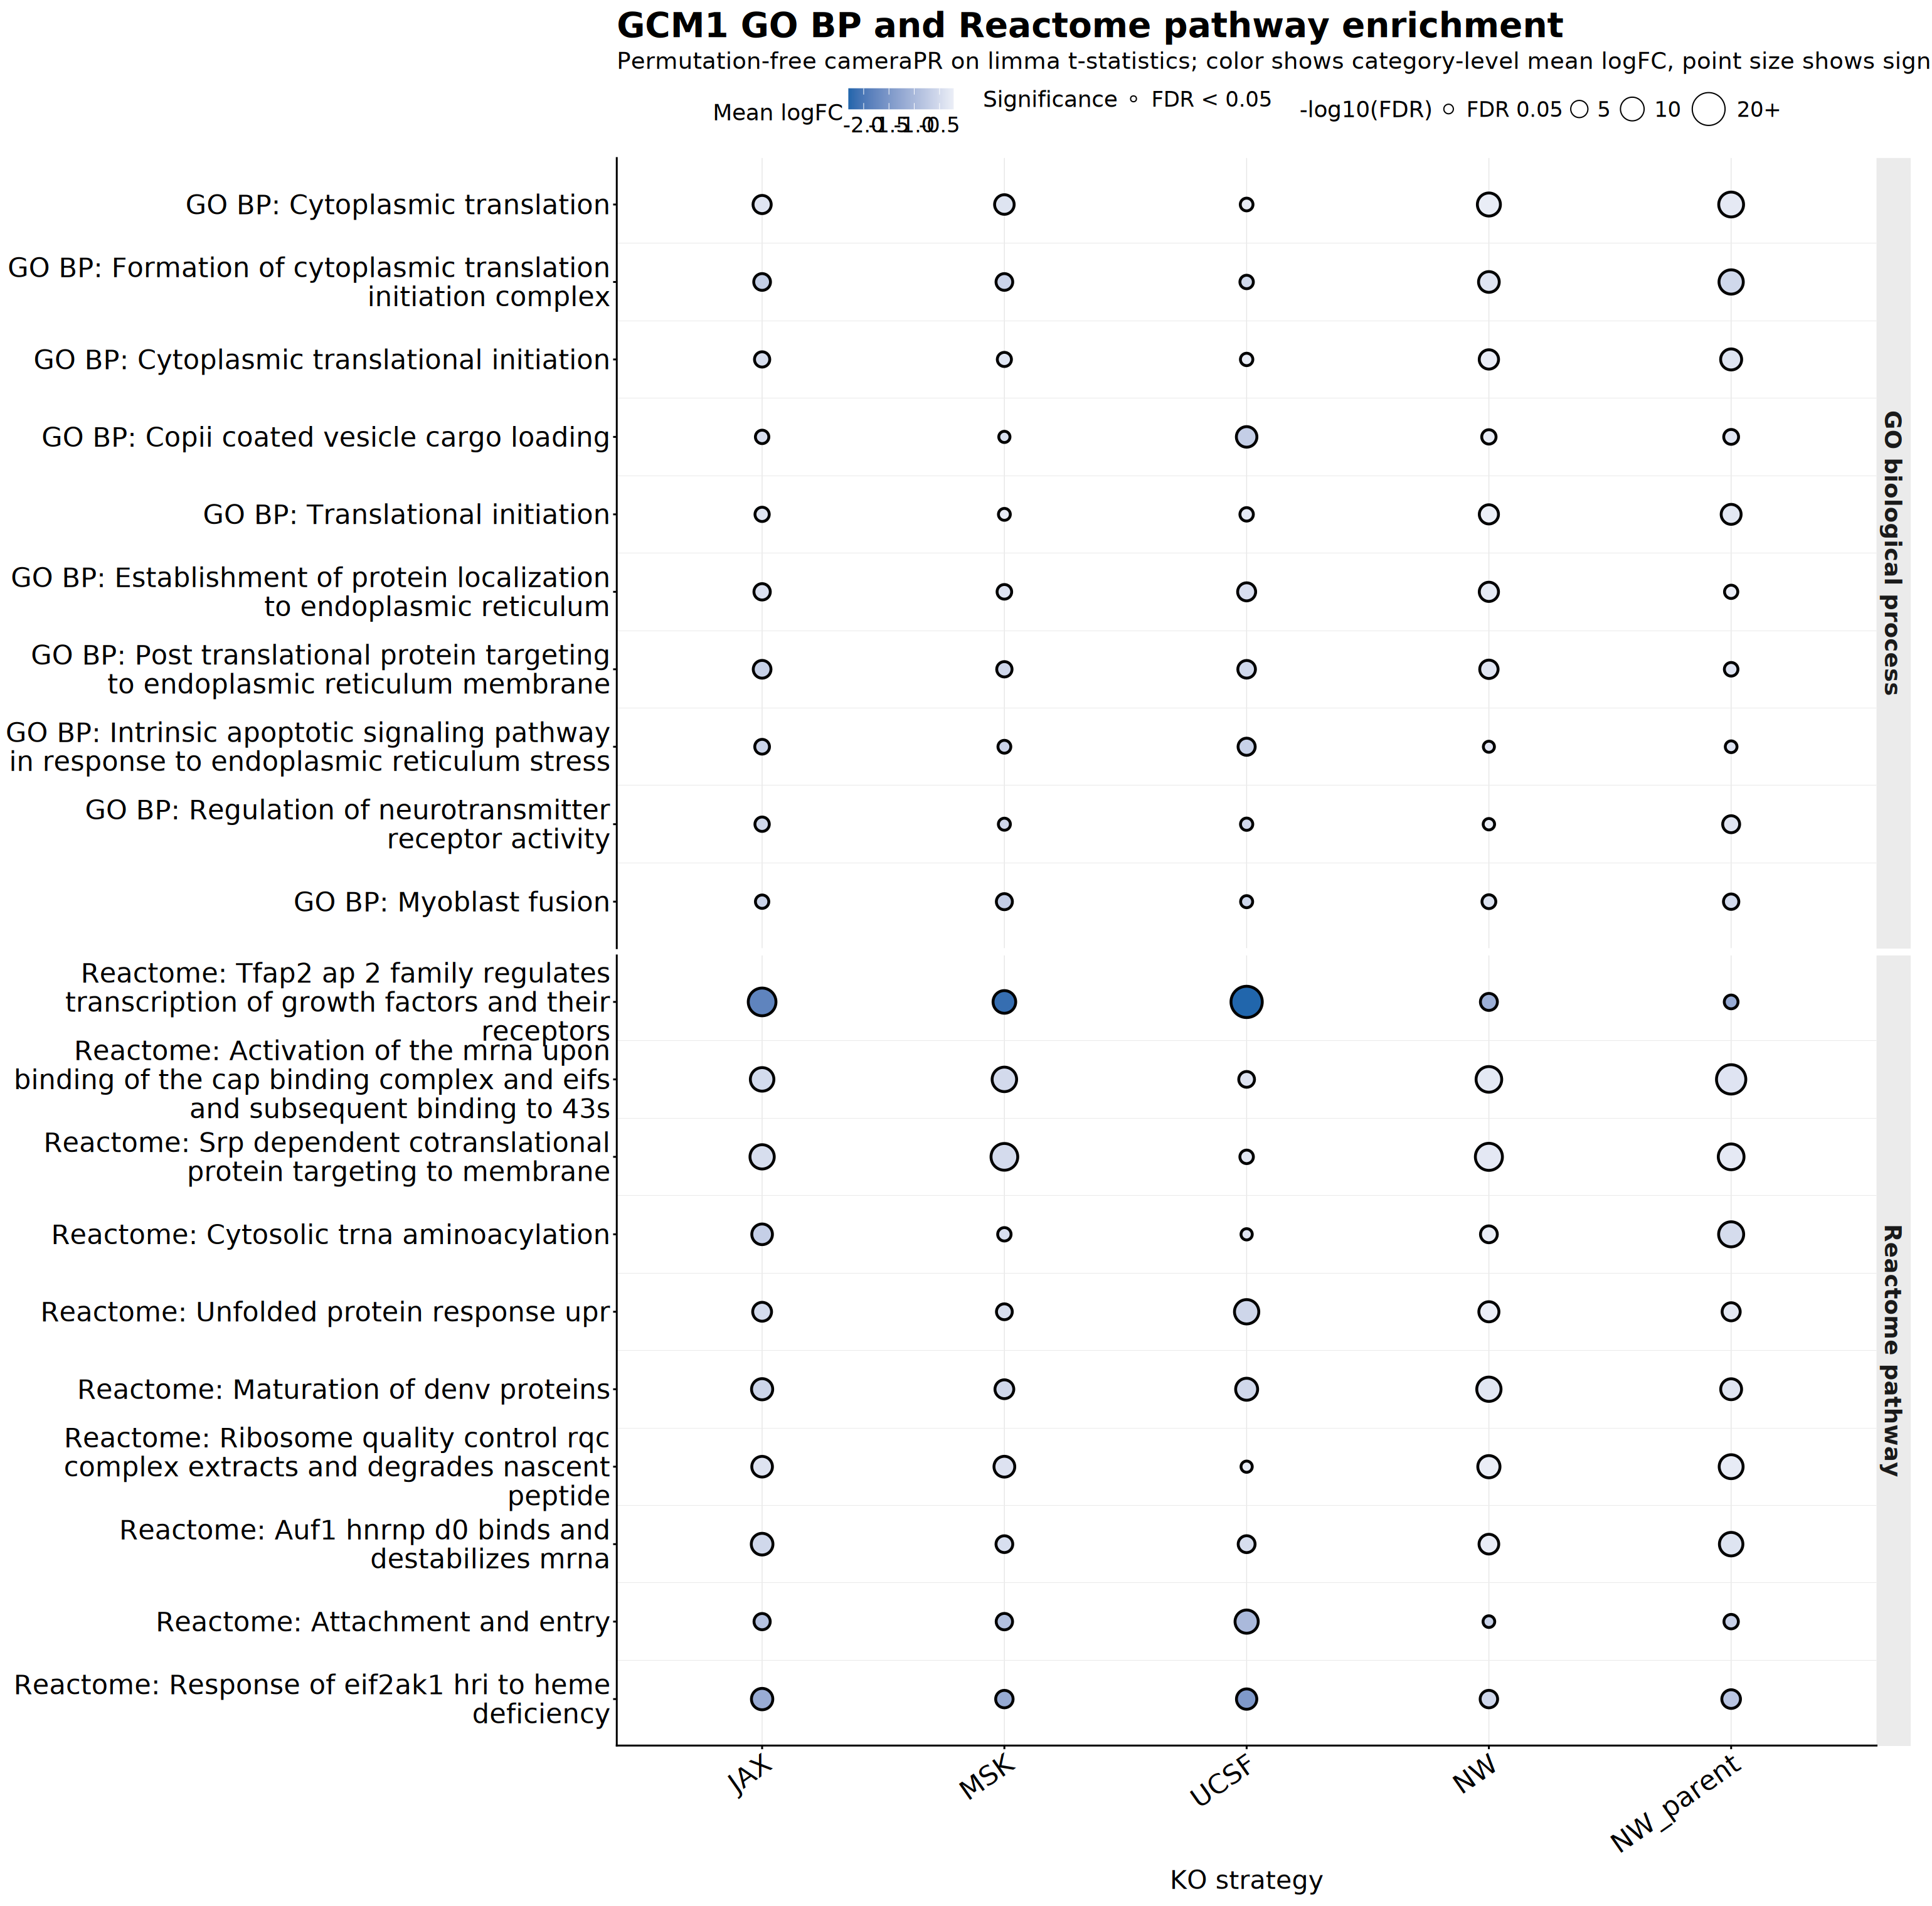

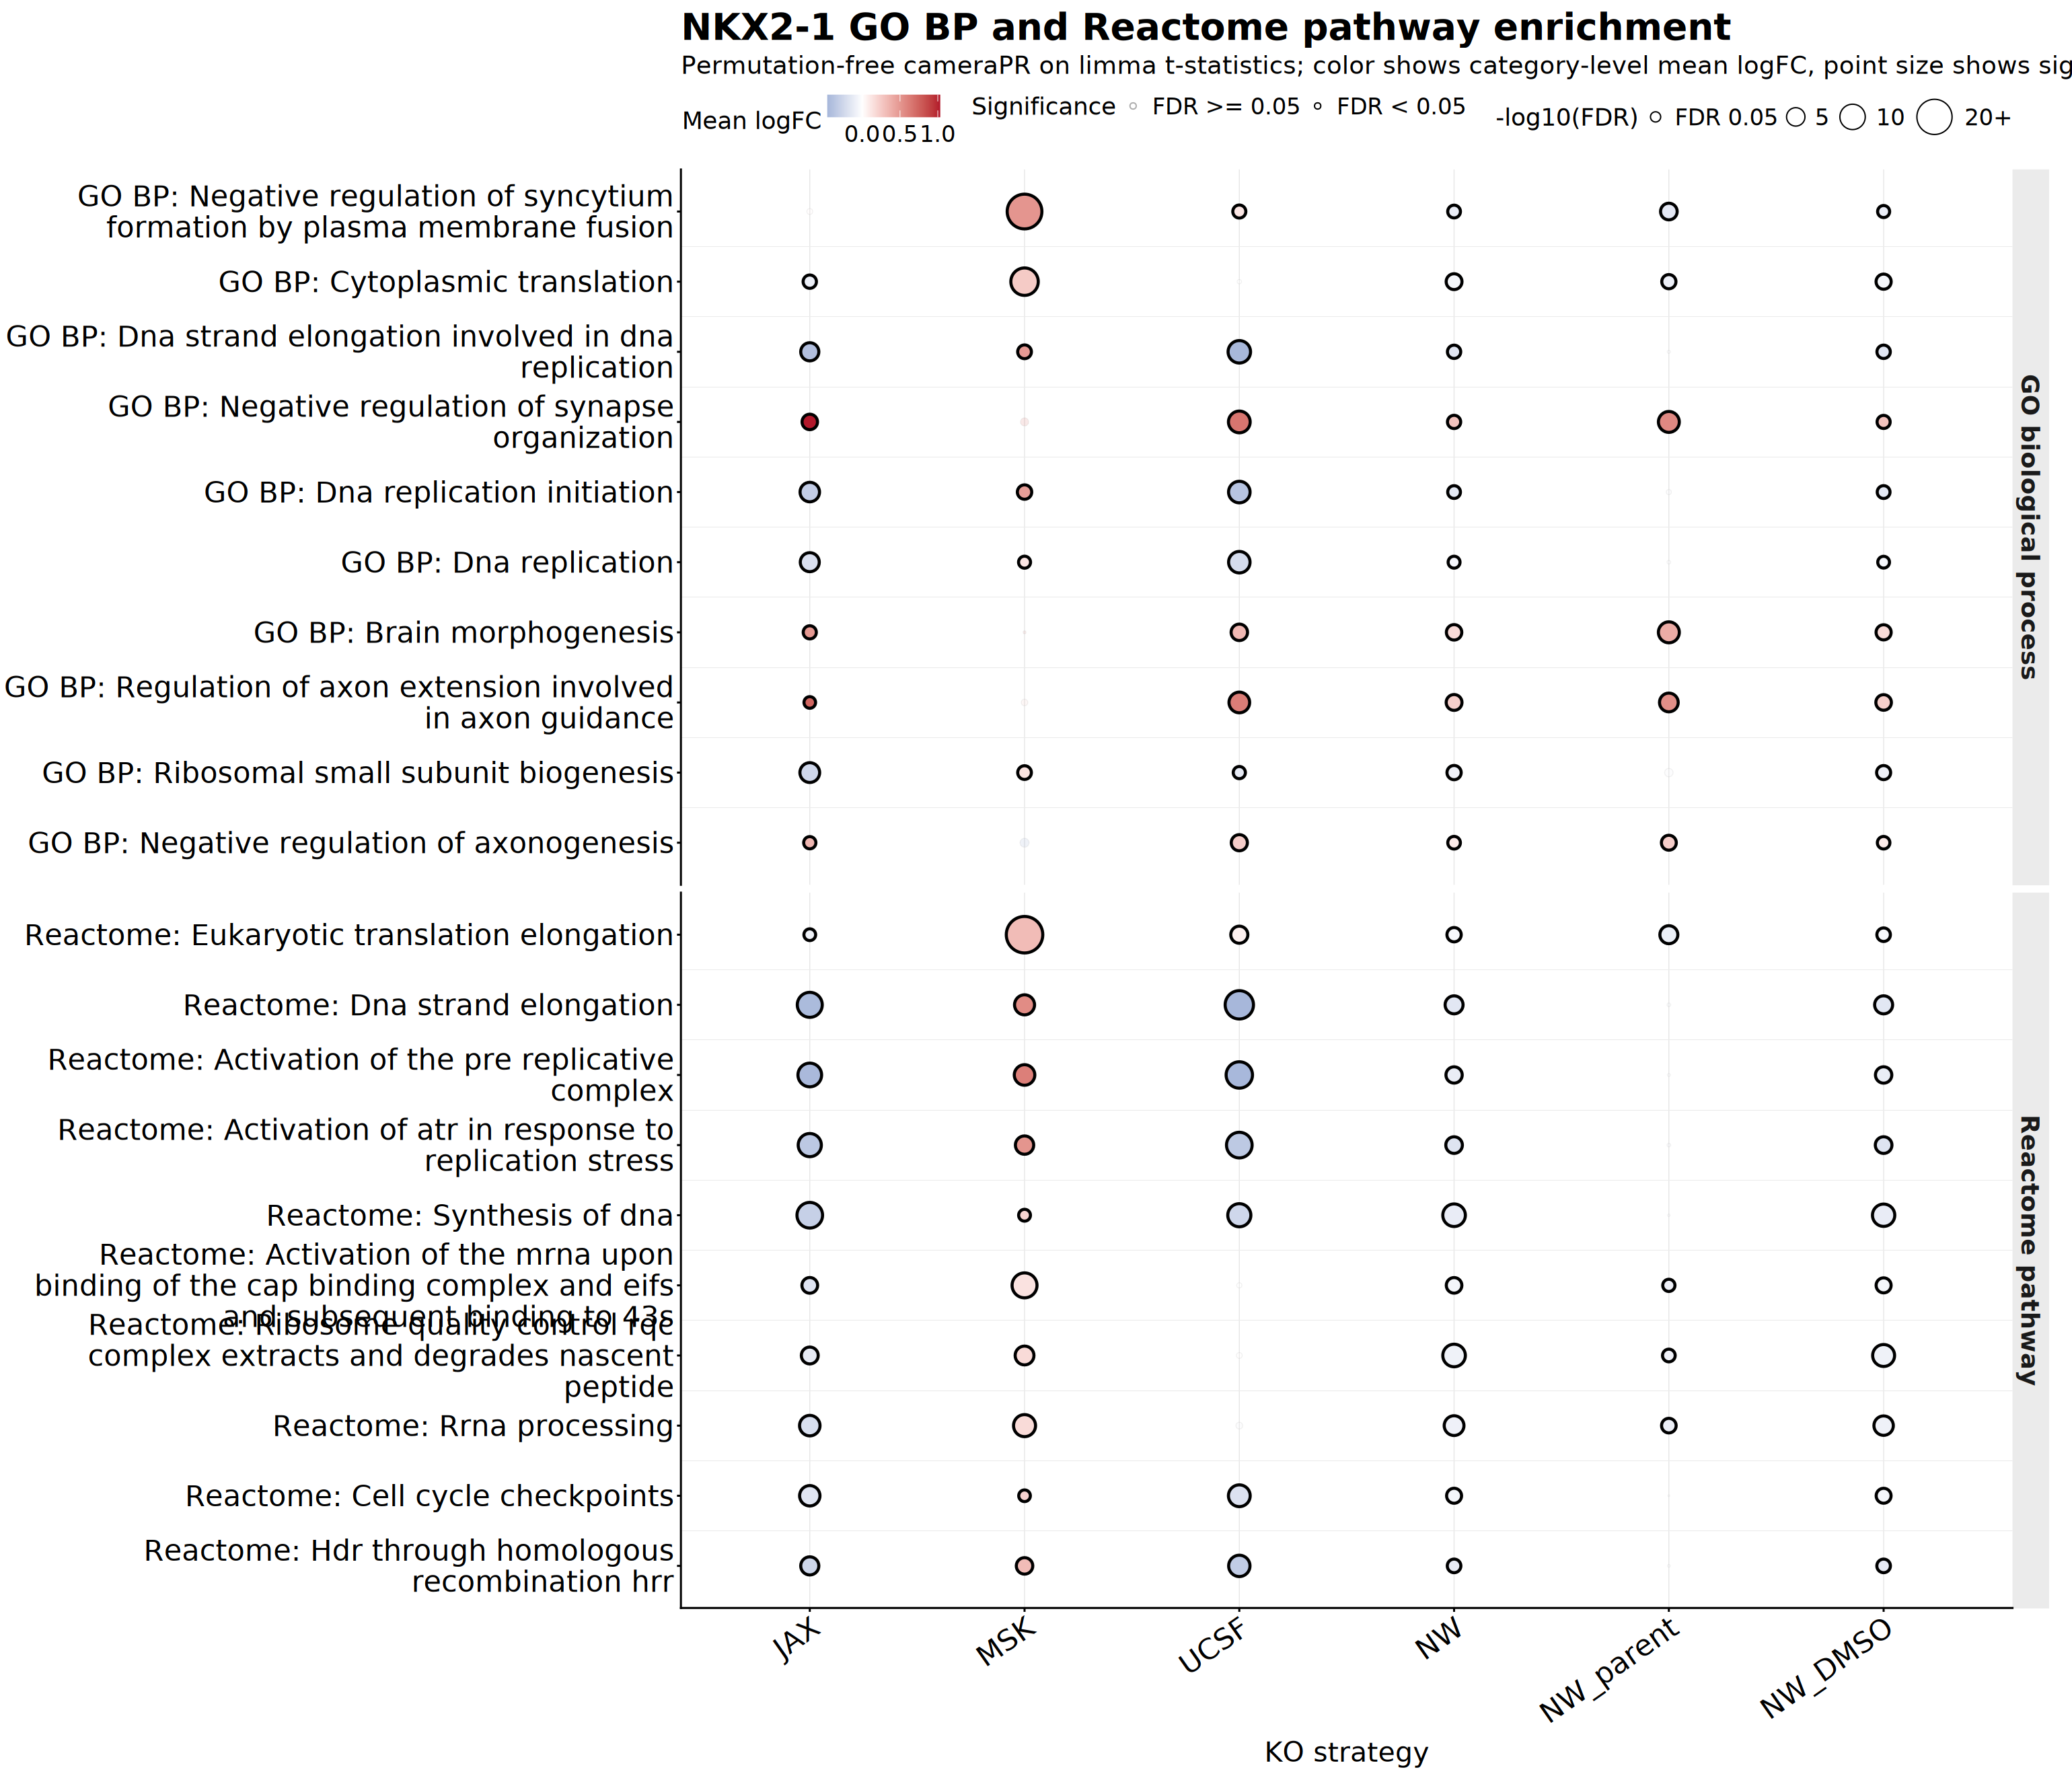

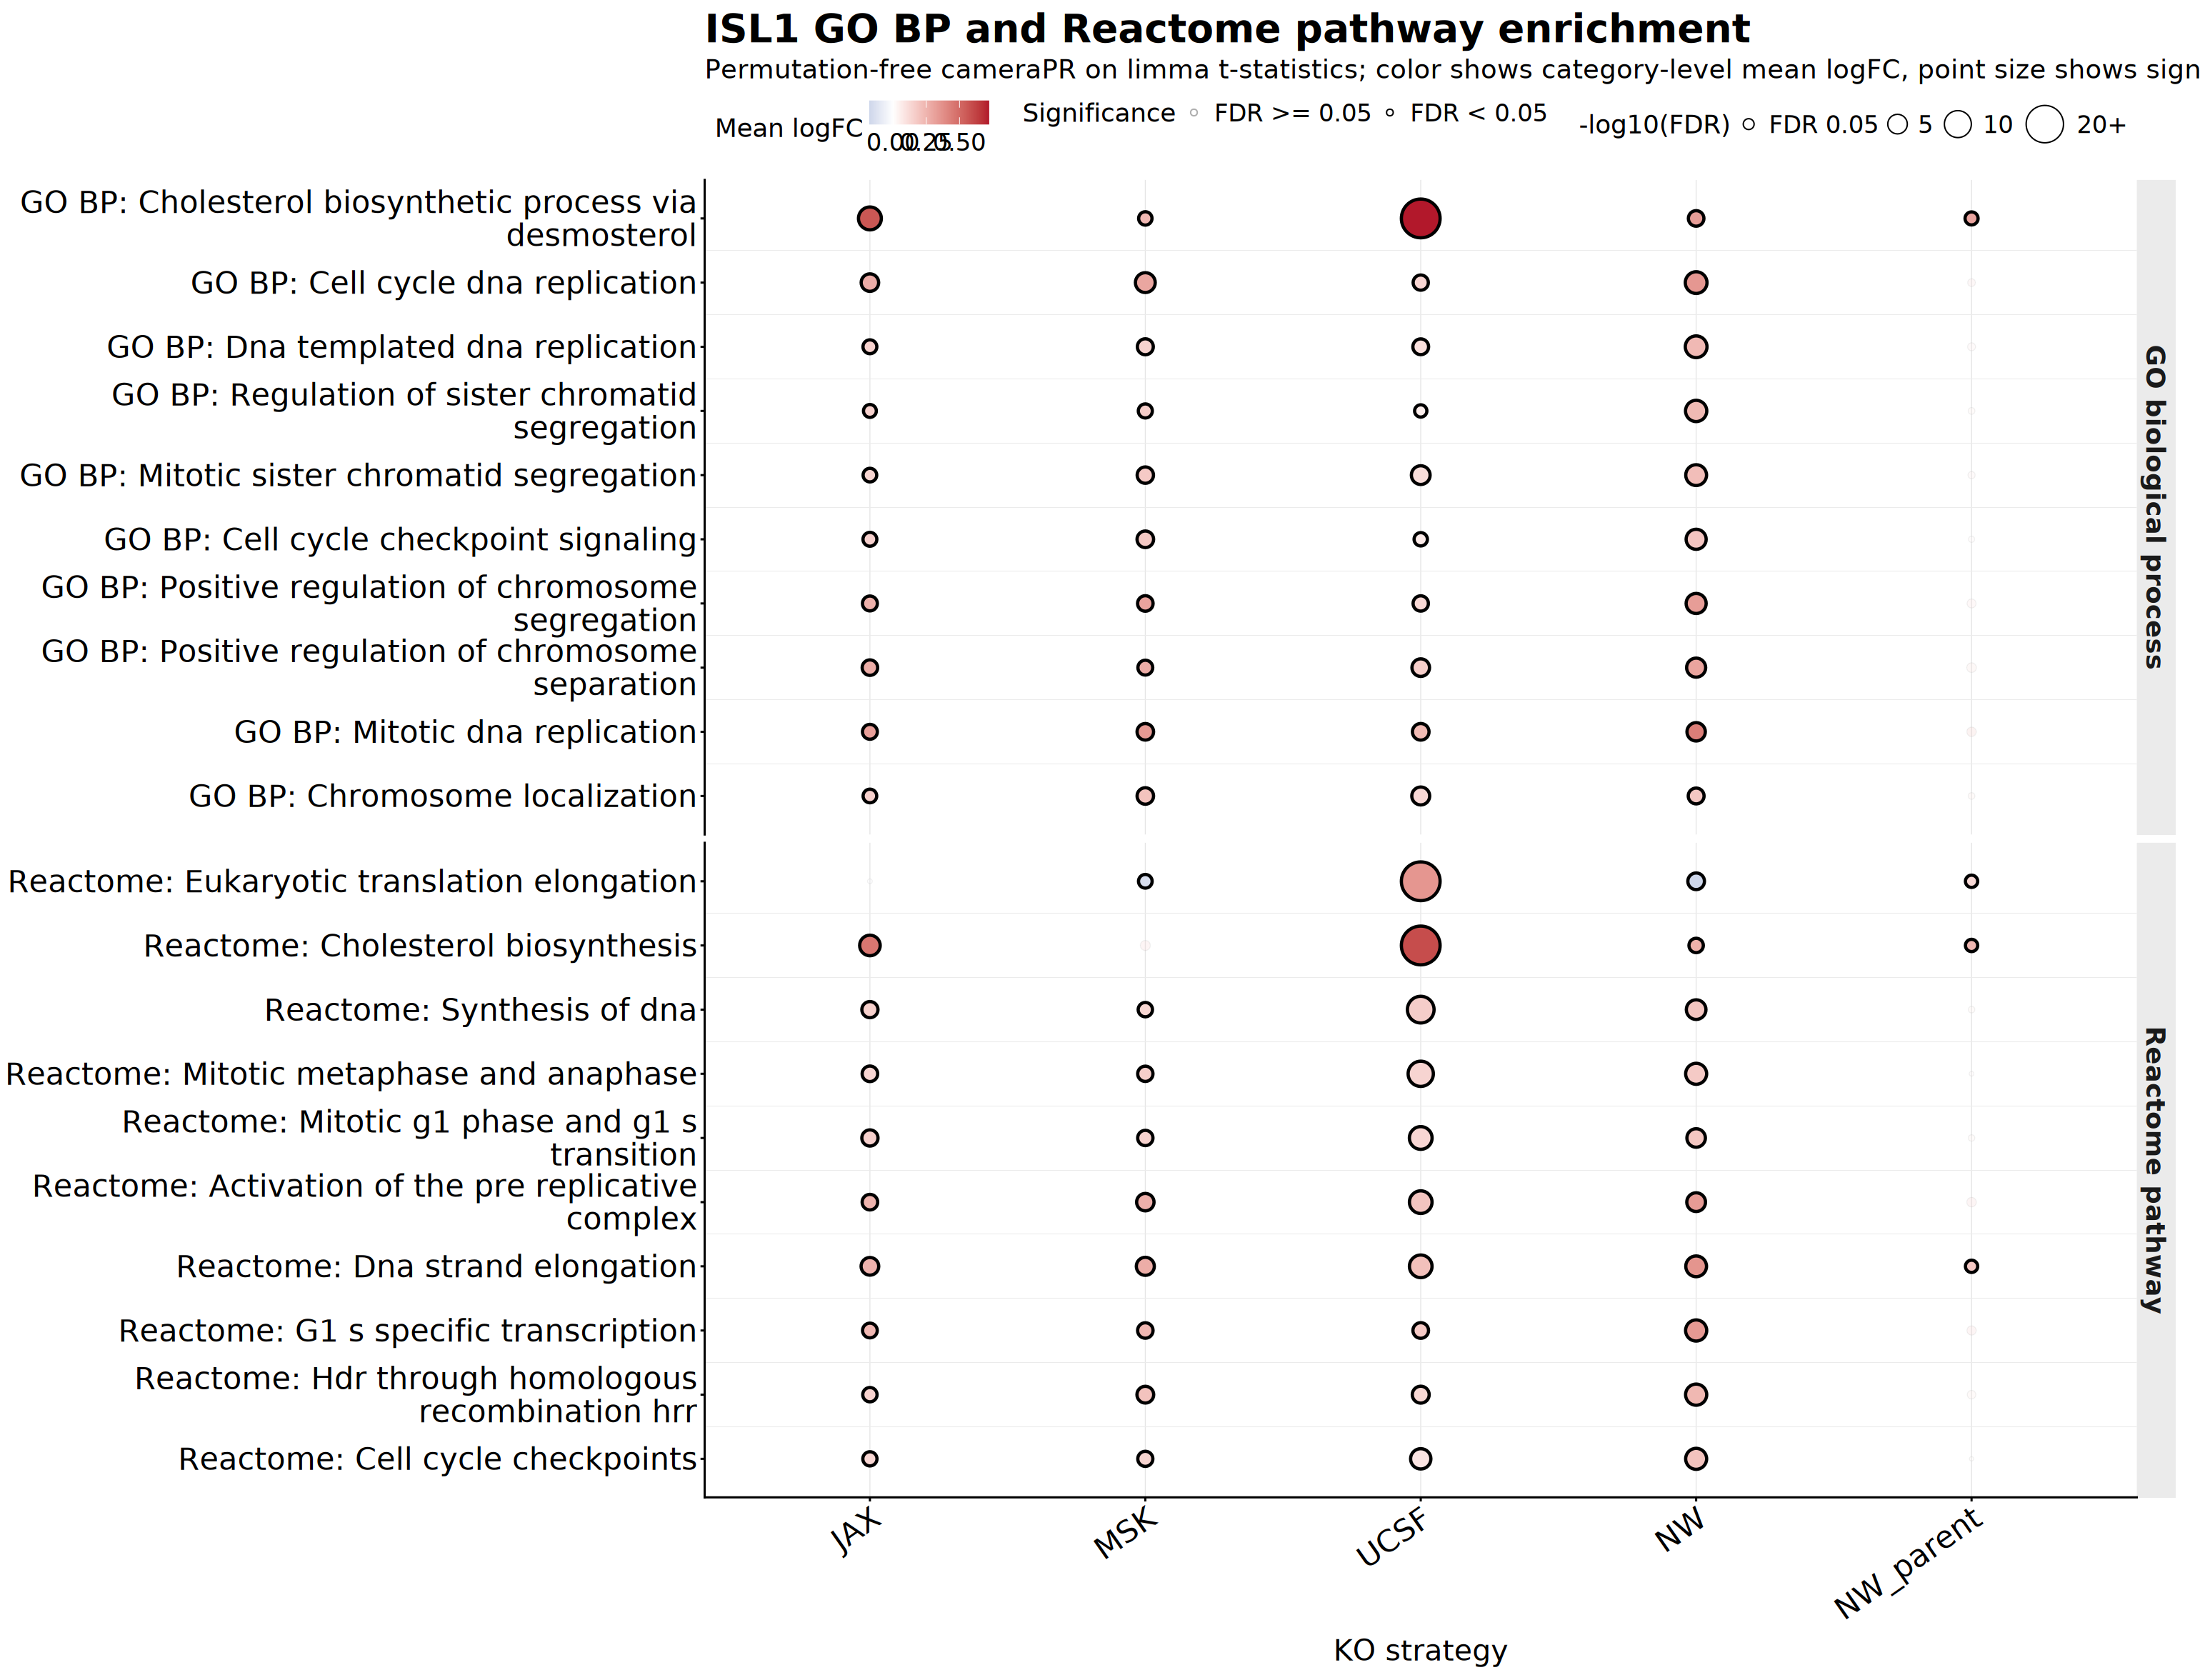

target_gene,figure,height
<chr>,<chr>,<dbl>
GCM1,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/gene_set_dot_heatmaps/GCM1_gene_set_dot_heatmap.png,23.8
NKX2-1,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/gene_set_dot_heatmaps/NKX2-1_gene_set_dot_heatmap.png,21.7
ISL1,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/gene_set_dot_heatmaps/ISL1_gene_set_dot_heatmap.png,18.9
EOMES,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/gene_set_dot_heatmaps/EOMES_gene_set_dot_heatmap.png,16.8


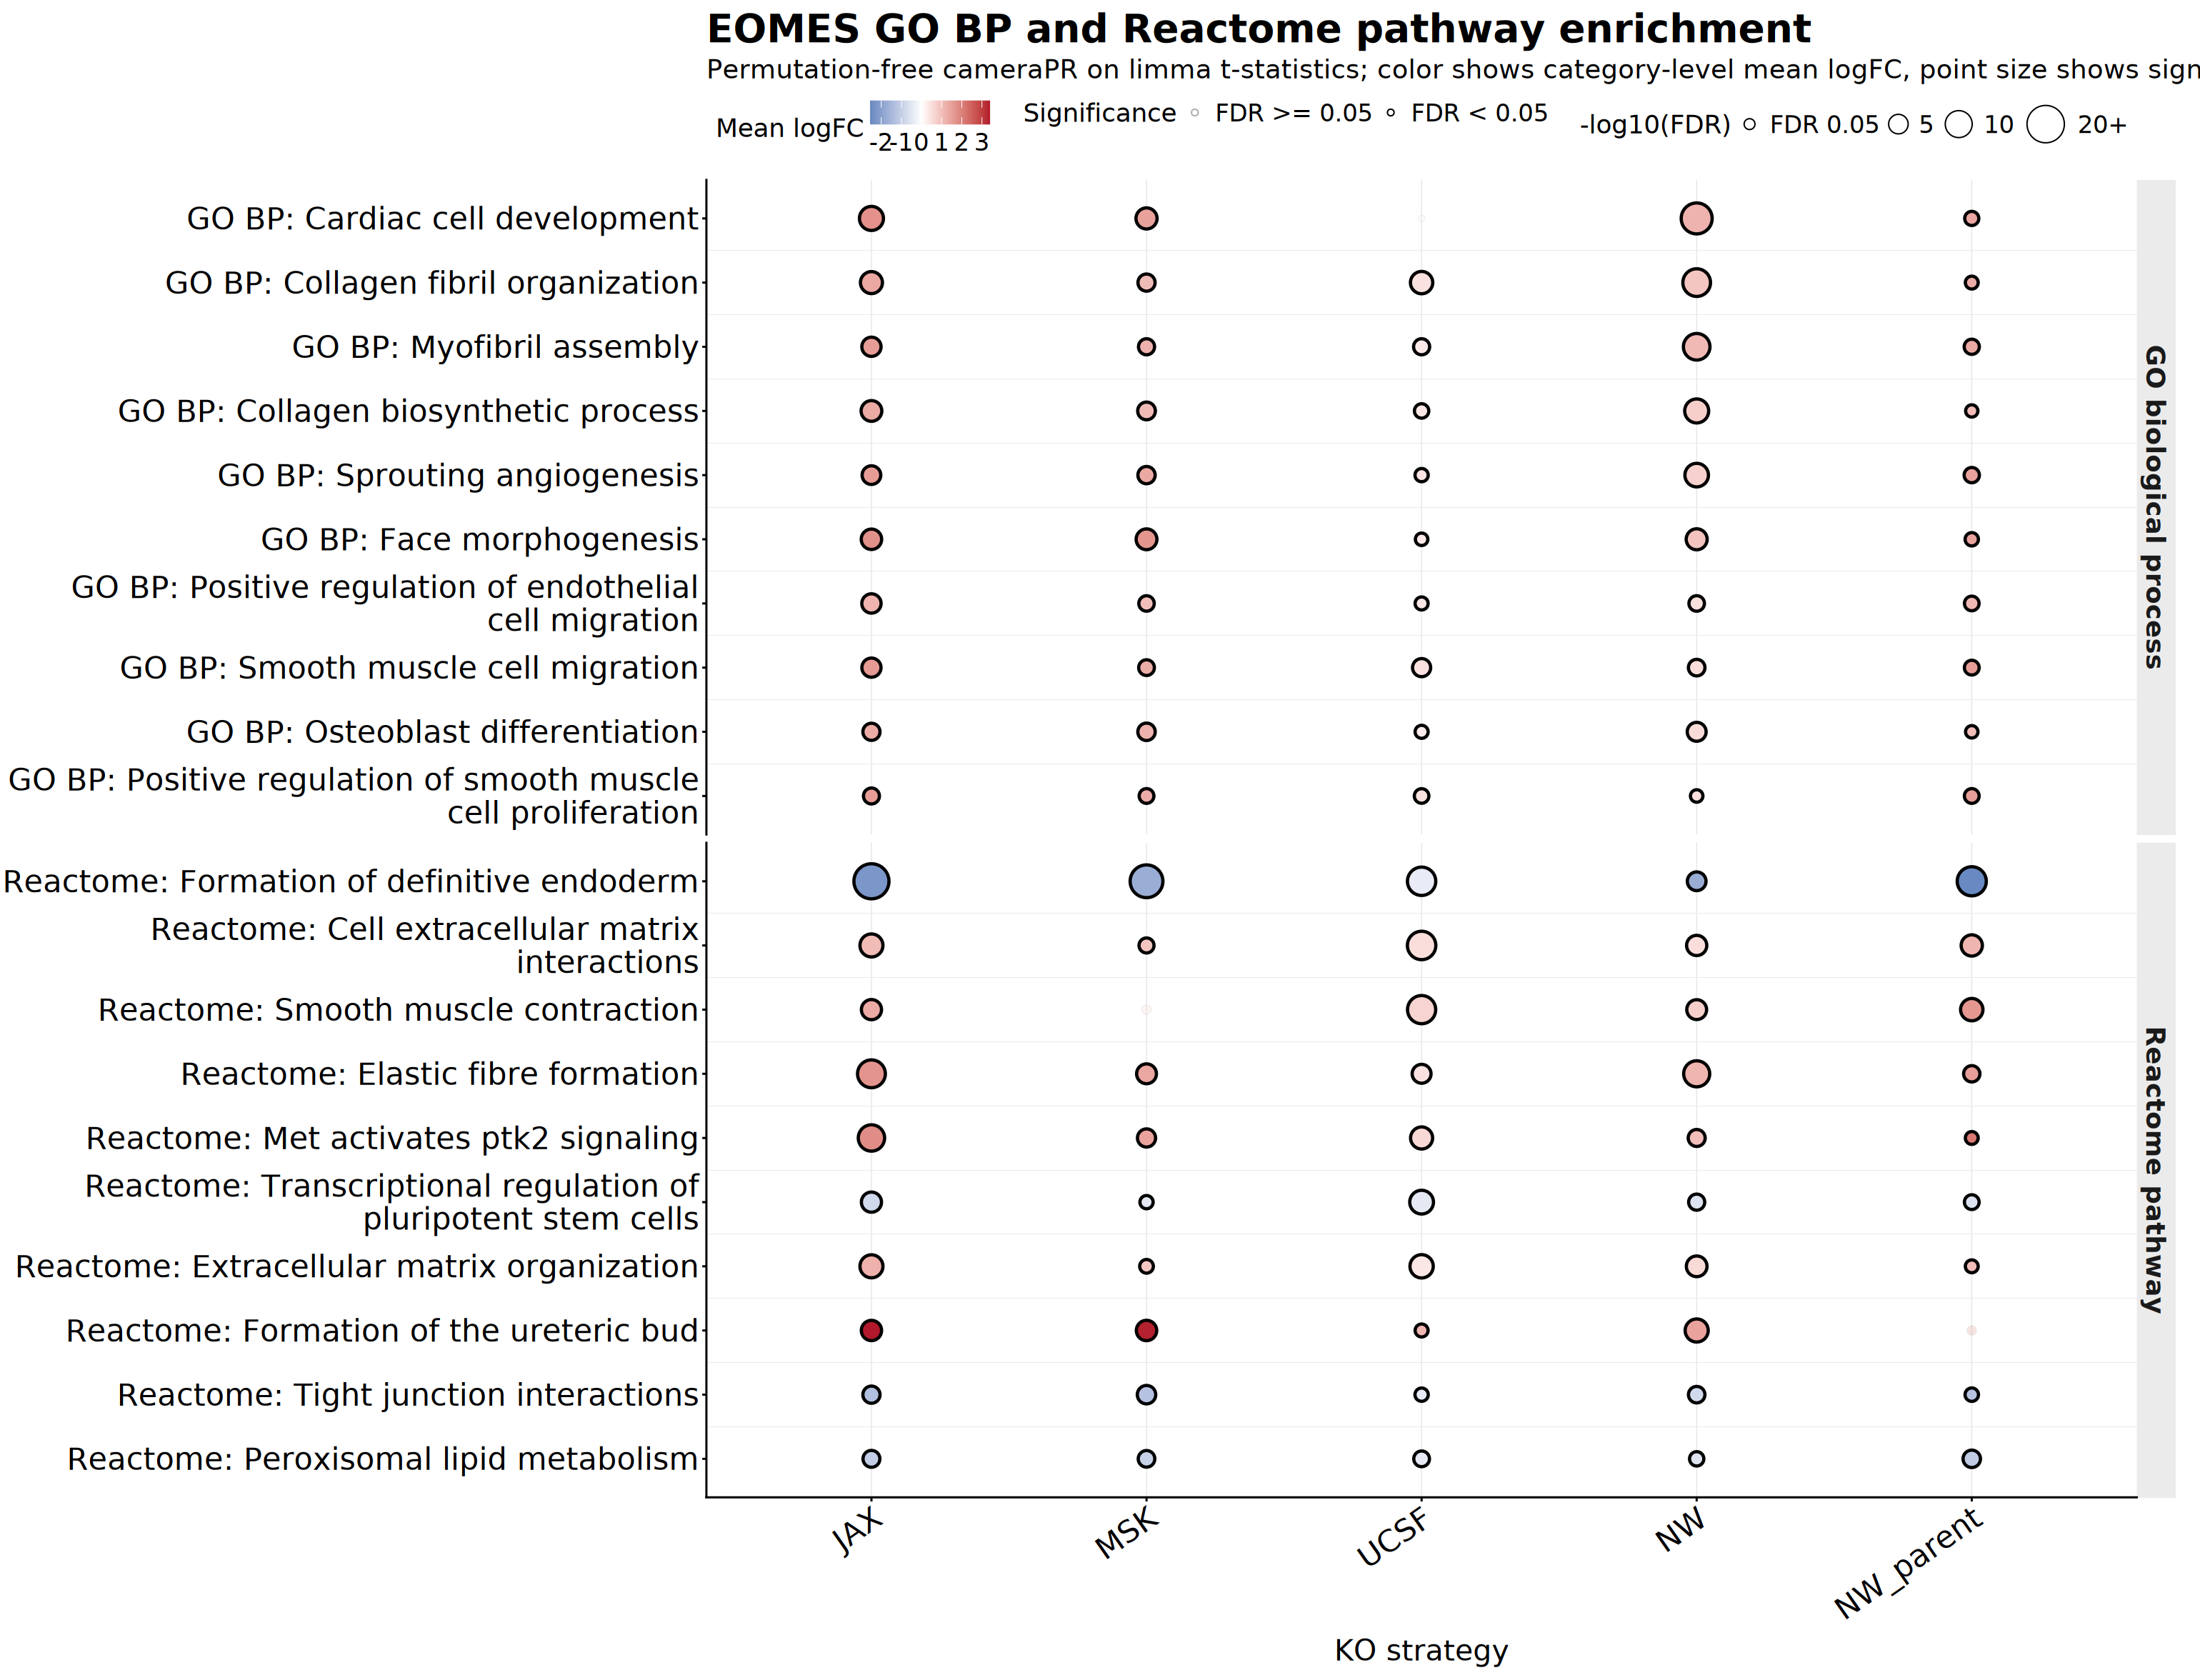

In [23]:
gene_set_top_terms_per_type <- 10
gene_set_candidate_terms_per_type <- 60
gene_set_heatmap_min_genes_tested <- 15
gene_set_heatmap_redundancy_jaccard_cutoff <- 0.45
gene_set_score_cap <- 20
gene_set_label_wrap_width <- 44
gene_set_comparison_cohorts <- c("JAX", "MSK", "UCSF", "NW", "NW_parent", "NW_DMSO")
print_gene_set_heatmaps <- TRUE

gene_set_heatmap_dir <- file.path(figure_dir, "gene_set_dot_heatmaps")
dir.create(gene_set_heatmap_dir, recursive = TRUE, showWarnings = FALSE)

if (!exists("safe_name")) {
  safe_name <- function(x) {
    x %>%
      as.character() %>%
      str_replace_all("[^A-Za-z0-9_-]+", "_") %>%
      str_replace_all("_+", "_") %>%
      str_replace_all("^_|_$", "")
  }
}

type_label_short <- function(x) {
  recode(as.character(x), "GO biological process" = "GO BP", "Reactome pathway" = "Reactome")
}

heatmap_term_gene_lookup <- gene_sets %>%
  group_by(type, category) %>%
  summarise(term_genes = list(unique(gene)), .groups = "drop")

filter_redundant_heatmap_terms <- function(term_rank, max_terms_per_type, jaccard_cutoff) {
  if (nrow(term_rank) == 0) {
    return(term_rank)
  }
  
  term_rank %>%
    left_join(heatmap_term_gene_lookup, by = c("type", "category")) %>%
    group_by(type) %>%
    group_modify(function(.x, .y) {
      keep <- rep(FALSE, nrow(.x))
      kept_genes <- list()
      
      for (i in seq_len(nrow(.x))) {
        genes_i <- .x$term_genes[[i]]
        if (is.null(genes_i) || length(genes_i) == 0 || all(is.na(genes_i))) {
          genes_i <- character()
        }
        
        too_similar <- any(vapply(kept_genes, function(genes_j) {
          union_n <- length(union(genes_i, genes_j))
          if (union_n == 0) {
            return(FALSE)
          }
          length(intersect(genes_i, genes_j)) / union_n >= jaccard_cutoff
        }, logical(1)))
        
        if (!too_similar) {
          keep[i] <- TRUE
          kept_genes[[length(kept_genes) + 1]] <- genes_i
        }
        
        if (sum(keep) >= max_terms_per_type) {
          break
        }
      }
      
      .x[keep, , drop = FALSE]
    }) %>%
    ungroup() %>%
    select(-term_genes)
}


select_heatmap_terms <- function(d) {
  ranked_terms <- d %>%
    filter(
      !is.na(FDR),
      !is.na(mean_logFC),
      !is.na(category_label),
      !is.na(n_genes_tested),
      n_genes_tested >= gene_set_heatmap_min_genes_tested
    ) %>%
    mutate(
      neg_log10_fdr = -log10(pmax(FDR, .Machine$double.xmin)),
      abs_effect = abs(mean_logFC)
    ) %>%
    group_by(type, category, category_label) %>%
    summarise(
      n_sig_cohorts = sum(FDR < fdr_cutoff, na.rm = TRUE),
      best_FDR = min(FDR, na.rm = TRUE),
      best_score = max(neg_log10_fdr, na.rm = TRUE),
      max_abs_effect = max(abs_effect, na.rm = TRUE),
      max_n_genes_tested = max(n_genes_tested, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    group_by(type) %>%
    arrange(desc(n_sig_cohorts), best_FDR, desc(max_abs_effect), desc(max_n_genes_tested), .by_group = TRUE) %>%
    slice_head(n = gene_set_candidate_terms_per_type) %>%
    ungroup()
  
  filter_redundant_heatmap_terms(
    ranked_terms,
    max_terms_per_type = gene_set_top_terms_per_type,
    jaccard_cutoff = gene_set_heatmap_redundancy_jaccard_cutoff
  ) %>%
    arrange(type, best_FDR, desc(max_abs_effect))
}


make_gene_set_heatmap_data <- function(gene1) {
  available_cohorts <- gene_set_comparison_cohorts[
    gene_set_comparison_cohorts %in% as.character(gene_set_results$cohort)
  ]
  
  d <- gene_set_results %>%
    filter(
      as.character(target_gene) == gene1,
      as.character(cohort) %in% available_cohorts
    ) %>%
    mutate(
      target_gene = as.character(target_gene),
      cohort = factor(as.character(cohort), levels = available_cohorts, ordered = TRUE),
      type = as.character(type),
      term_id = paste(type, category, sep = "___"),
      term_label = paste0(type_label_short(type), ": ", category_label)
    )
  
  selected_terms <- select_heatmap_terms(d) %>%
    mutate(
      type = as.character(type),
      term_id = paste(type, category, sep = "___"),
      term_label = paste0(type_label_short(type), ": ", category_label),
      term_label_wrapped = str_wrap(term_label, width = gene_set_label_wrap_width)
    )
  
  if (nrow(selected_terms) == 0) {
    return(tibble())
  }
  
  term_levels <- rev(selected_terms$term_id)
  term_labels <- setNames(selected_terms$term_label_wrapped, selected_terms$term_id)
  
  d %>%
    semi_join(selected_terms %>% select(term_id), by = "term_id") %>%
    mutate(
      term_id = factor(term_id, levels = term_levels),
      term_label_wrapped = term_labels[as.character(term_id)],
      neg_log10_fdr = -log10(pmax(FDR, .Machine$double.xmin)),
      neg_log10_fdr_plot = pmin(neg_log10_fdr, gene_set_score_cap),
      is_significant_term = FDR < fdr_cutoff,
      type = factor(type, levels = c("GO biological process", "Reactome pathway"))
    )
}

make_gene_set_heatmap <- function(gene1) {
  plot_df <- make_gene_set_heatmap_data(gene1)
  if (nrow(plot_df) == 0) {
    return(NULL)
  }
  
  term_label_stats <- plot_df %>%
    distinct(term_id, term_label_wrapped) %>%
    mutate(label_lines = str_count(term_label_wrapped, fixed("\n")) + 1)
  
  term_label_lookup <- term_label_stats %>%
    select(term_id, term_label_wrapped) %>%
    tibble::deframe()
  
  n_terms <- n_distinct(plot_df$term_id)
  label_height_units <- sum(term_label_stats$label_lines, na.rm = TRUE)
  display_width <- 22
  display_height <- max(12, 0.7 * label_height_units)
  plot_width <- display_width
  plot_height <- display_height
  hline_df <- plot_df %>%
    distinct(type, term_id) %>%
    count(type, name = "n_terms_type") %>%
    mutate(yintercept = purrr::map(n_terms_type, ~ if (.x > 1) seq(1.5, .x - 0.5, by = 1) else numeric())) %>%
    tidyr::unnest(yintercept)
  
  ggplot(plot_df, aes(x = cohort, y = term_id)) +
    geom_point(
      aes(
        size = neg_log10_fdr_plot,
        fill = mean_logFC,
        alpha = is_significant_term,
        color = is_significant_term,
        stroke = is_significant_term
      ),
      shape = 21
    ) +
    geom_hline(
      data = hline_df,
      aes(yintercept = yintercept),
      inherit.aes = FALSE,
      color = "grey92",
      linewidth = 0.2
    ) +
    scale_y_discrete(labels = term_label_lookup, drop = TRUE) +
    scale_fill_gradient2(
      low = "#2166AC",
      mid = "white",
      high = "#B2182B",
      midpoint = 0,
      name = "Mean logFC"
    ) +
    scale_size_area(
      max_size = 12,
      limits = c(0, gene_set_score_cap),
      breaks = c(-log10(fdr_cutoff), 5, 10, 20),
      labels = c("FDR 0.05", "5", "10", paste0(gene_set_score_cap, "+")),
      name = "-log10(FDR)"
    ) +
    scale_color_manual(
      values = c(`TRUE` = "black", `FALSE` = "grey68"),
      labels = c(`TRUE` = "FDR < 0.05", `FALSE` = "FDR >= 0.05"),
      name = "Significance"
    ) +
    scale_discrete_manual(
      aesthetics = "stroke",
      values = c(`TRUE` = 1.25, `FALSE` = 0.35),
      guide = "none"
    ) +
    scale_alpha_manual(values = c(`TRUE` = 1, `FALSE` = 0.18), guide = "none") +
    facet_grid(type ~ ., scales = "free_y", space = "free_y") +
    labs(
      x = "KO strategy",
      y = NULL,
      title = paste0(gene1, " GO BP and Reactome pathway enrichment"),
      subtitle = "Permutation-free cameraPR on limma t-statistics; color shows category-level mean logFC, point size shows significance"
    ) +
    theme(
      legend.position = "top",
      text = element_text(size = 20),
      axis.text.x = element_text(size = 22, angle = 35, hjust = 1),
      axis.text.y = element_text(size = 22, lineheight = 0.9),
      axis.title.x = element_text(size = 21, margin = margin(t = 10)),
      legend.title = element_text(size = 18),
      legend.text = element_text(size = 17),
      strip.text.y = element_text(size = 19, face = "bold"),
      strip.background = element_rect(fill = "grey92", color = NA),
      panel.grid.major.x = element_line(color = "grey90", linewidth = 0.25),
      panel.grid.major.y = element_blank(),
      panel.grid.minor = element_blank(),
      plot.title = element_text(face = "bold", size = 28),
      plot.subtitle = element_text(size = 19),
      plot.margin = margin(10, 18, 10, 10)
    ) -> p
  
  attr(p, "plot_width") <- plot_width
  attr(p, "plot_height") <- plot_height
  attr(p, "display_width") <- display_width
  attr(p, "display_height") <- display_height
  p
}

gene_set_heatmap_index <- tibble()

for (gene1 in target_genes) {
  p <- make_gene_set_heatmap(gene1)
  if (is.null(p)) {
    next
  }
  
  out_file <- file.path(gene_set_heatmap_dir, paste0(safe_name(gene1), "_gene_set_dot_heatmap.png"))
  plot_width <- attr(p, "plot_width")
  plot_height <- attr(p, "plot_height")
  
  if (print_gene_set_heatmaps) {
    display_width <- attr(p, "display_width")
    display_height <- attr(p, "display_height")
    set_notebook_plot_size(width = display_width, height = display_height, res = 140, pointsize = 18)
    print(p)
  }
  
  ggsave(
    out_file,
    plot = p,
    width = plot_width,
    height = plot_height,
    device = "png",
    dpi = 300,
    bg = "transparent",
    limitsize = FALSE
  )
  
  gene_set_heatmap_index <- bind_rows(
    gene_set_heatmap_index,
    tibble(target_gene = gene1, figure = out_file, height = plot_height)
  )
}

gene_set_heatmap_index


## Visualize pre-ranked GSEA as KO-strategy dot heatmaps

Show the pre-ranked GSEA results in the same layout as the cameraPR gene-set heatmaps. Rows are GO BP or Reactome categories, columns are KO strategies, fill color shows normalized enrichment score, point size shows GSEA FDR strength, and a black point boundary marks FDR-significant categories.


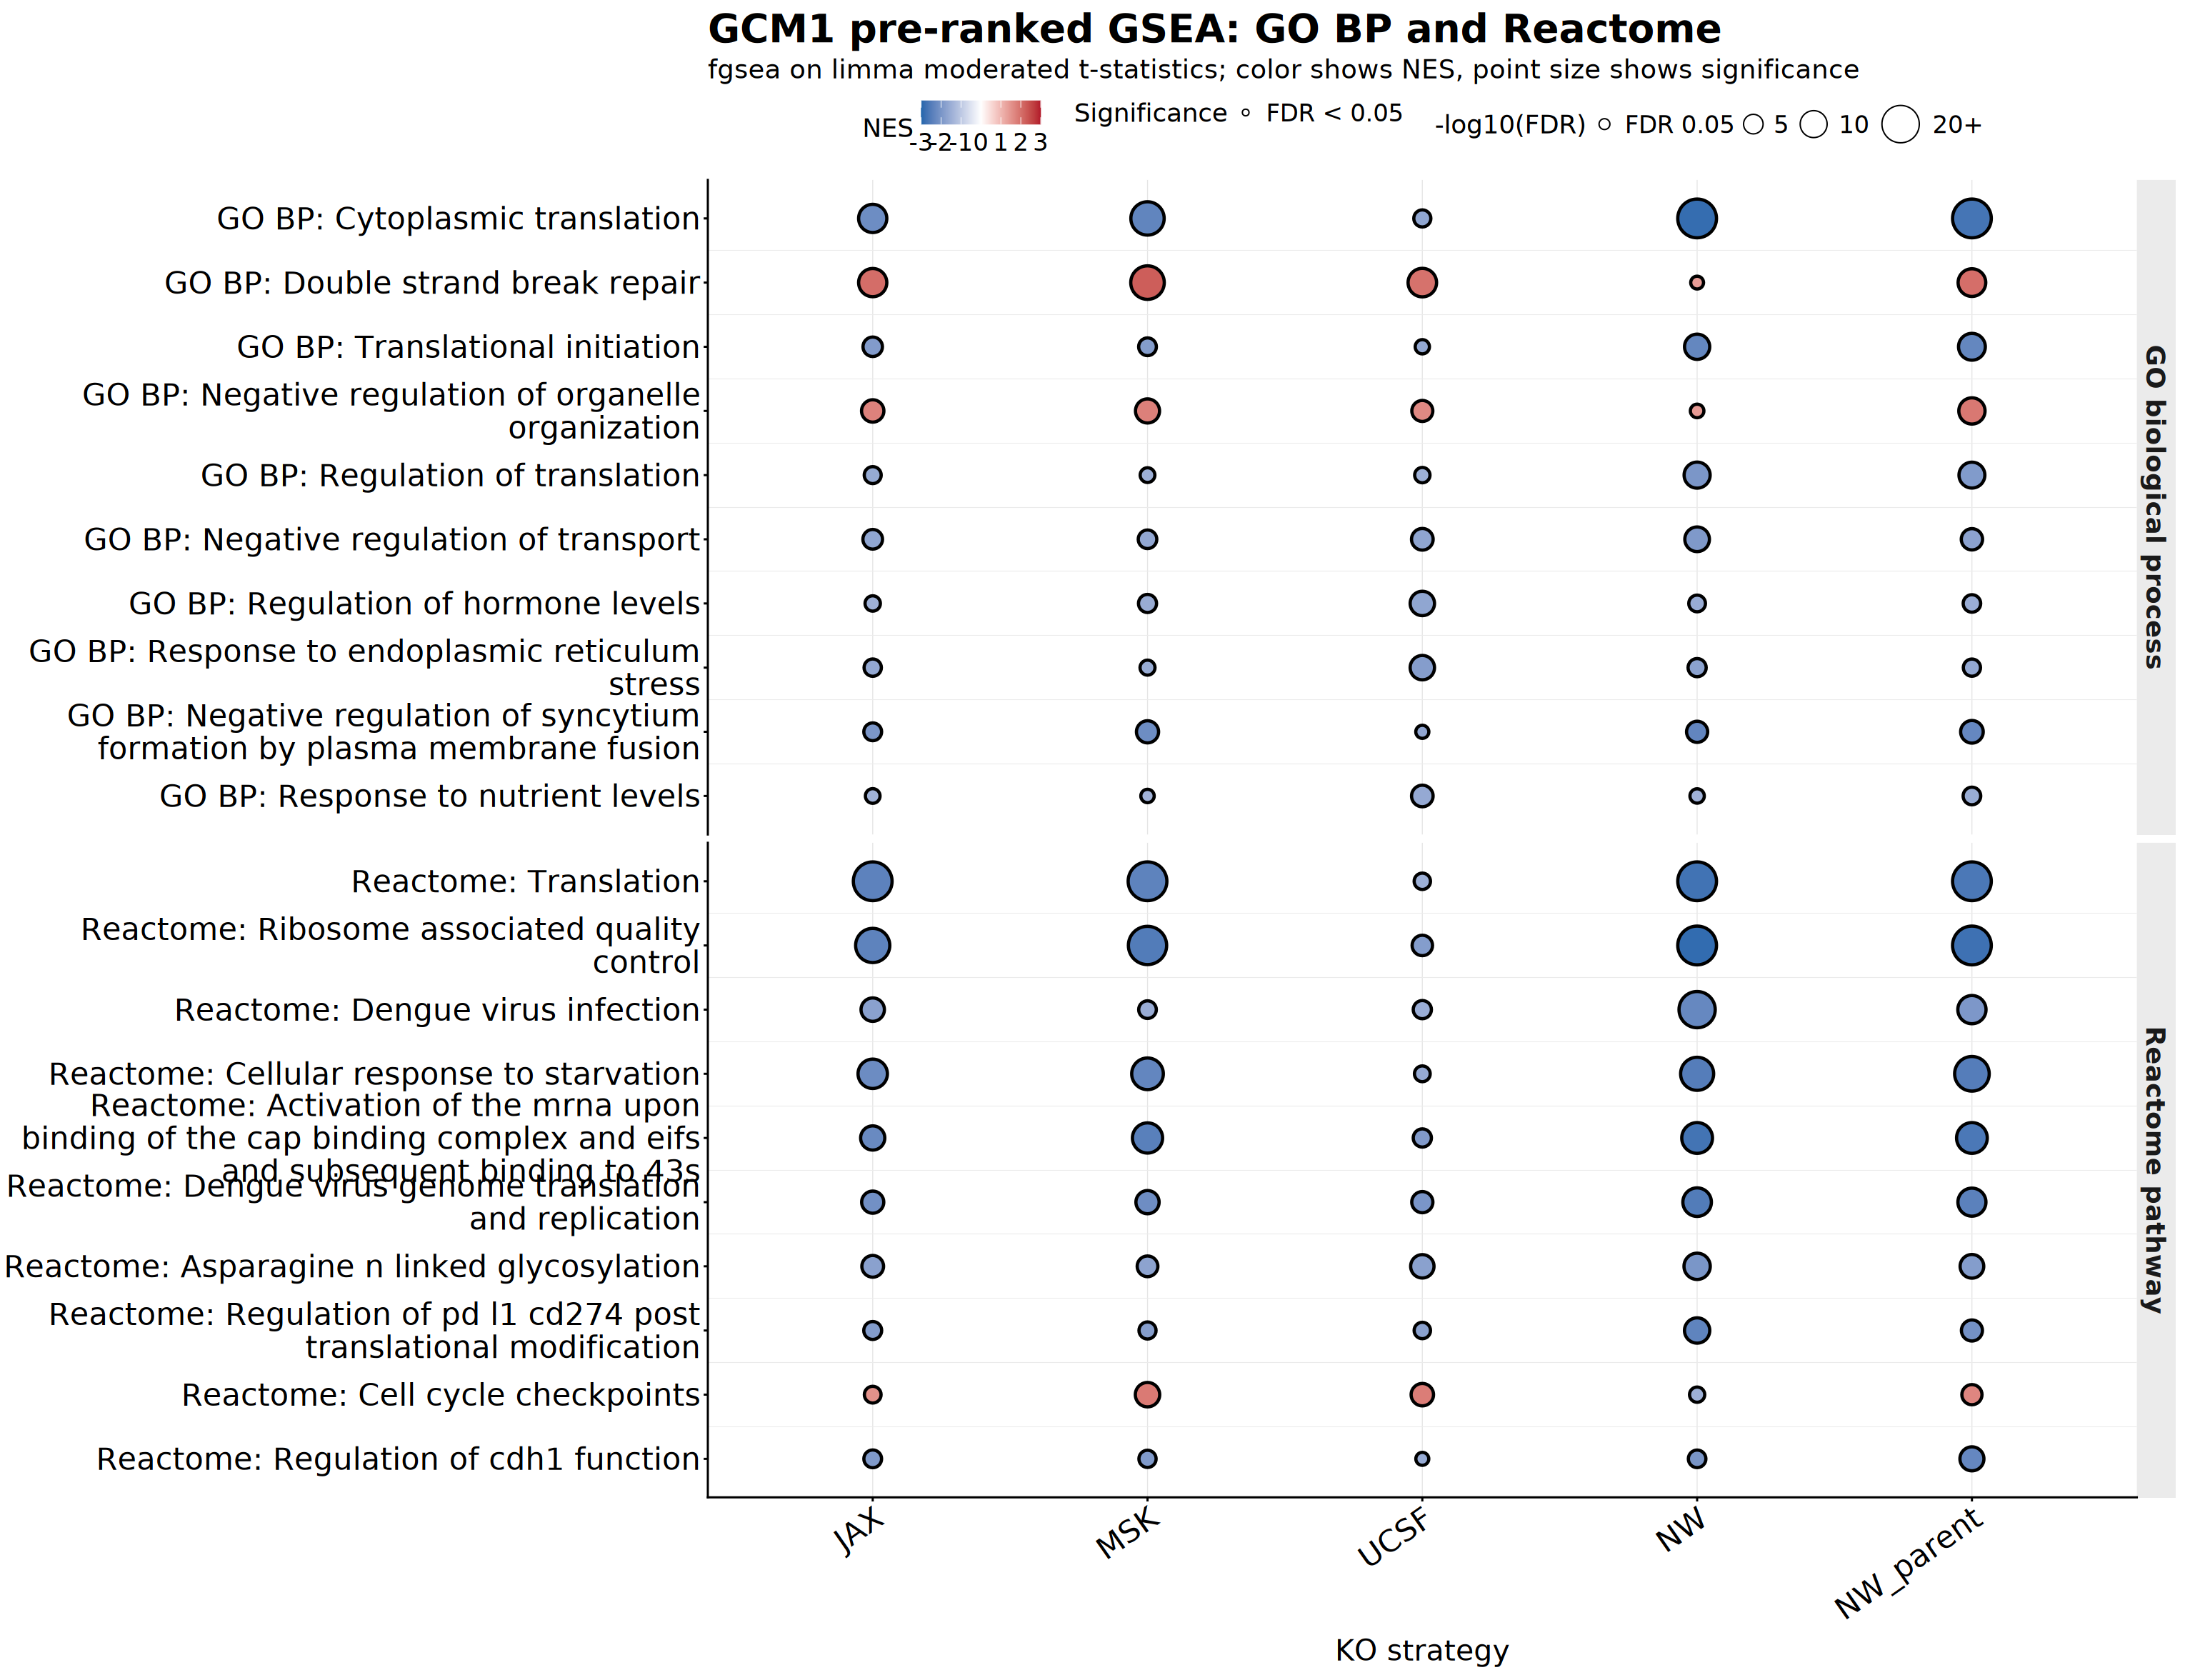

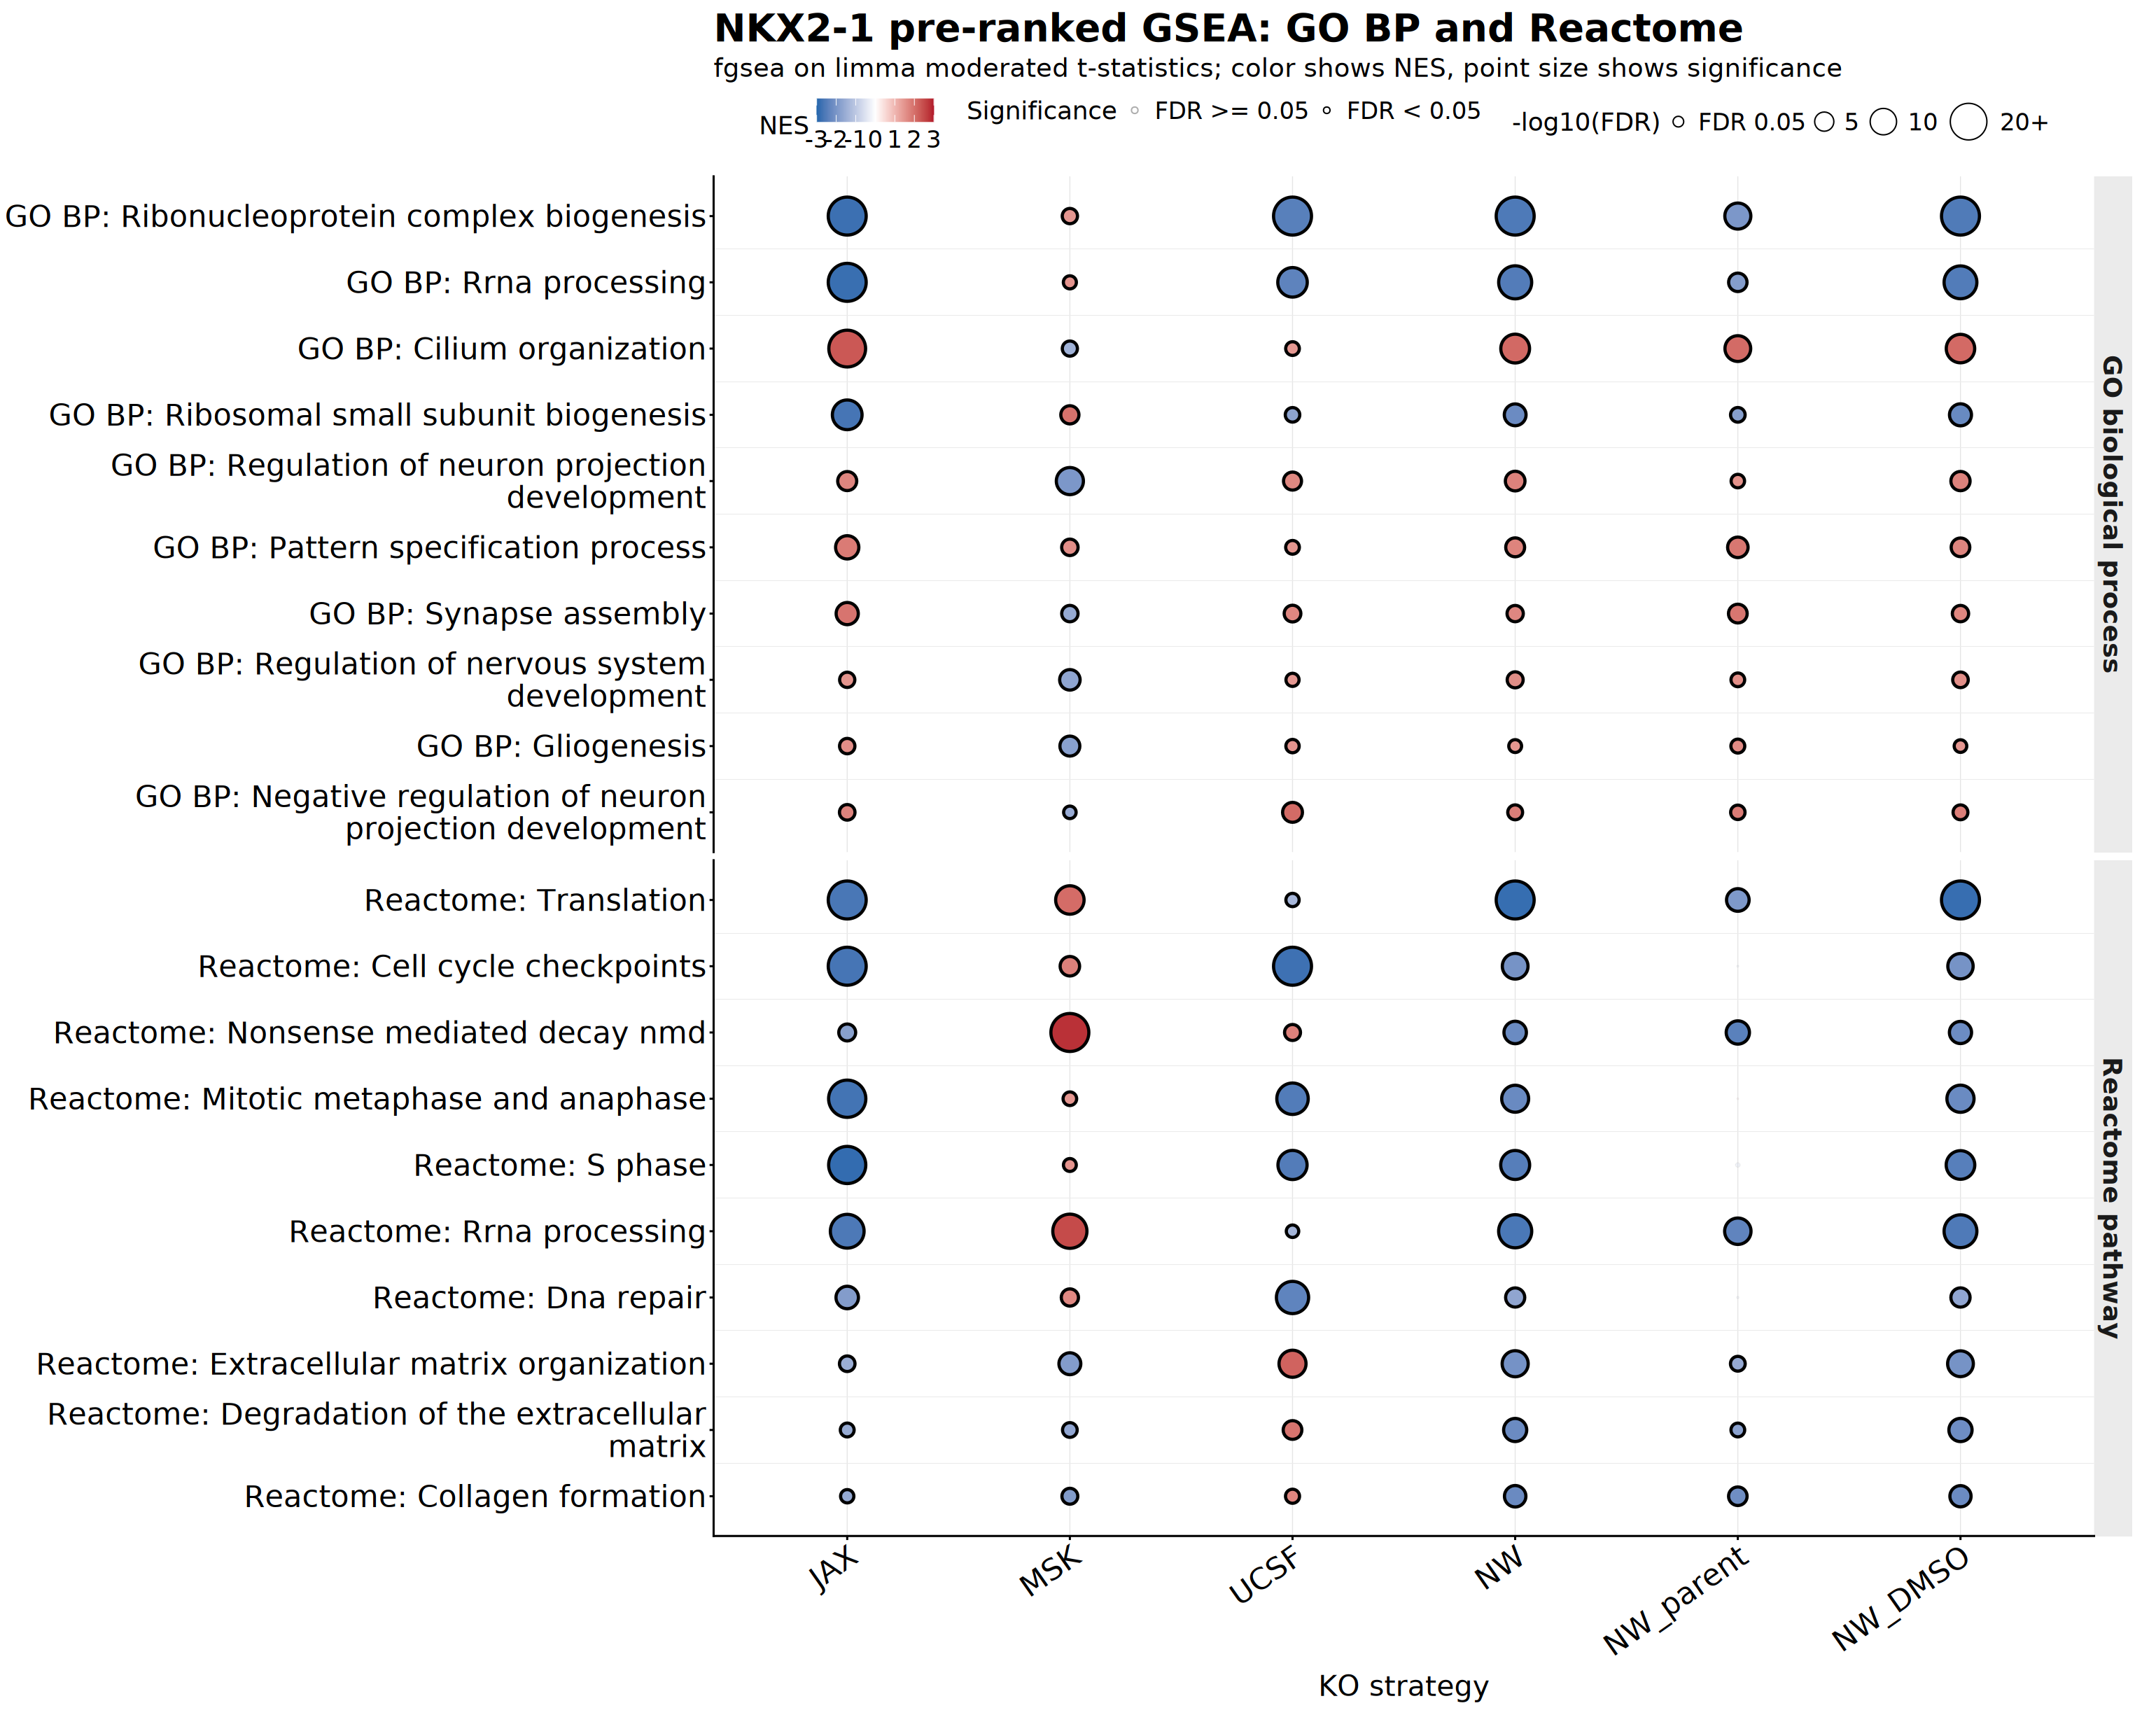

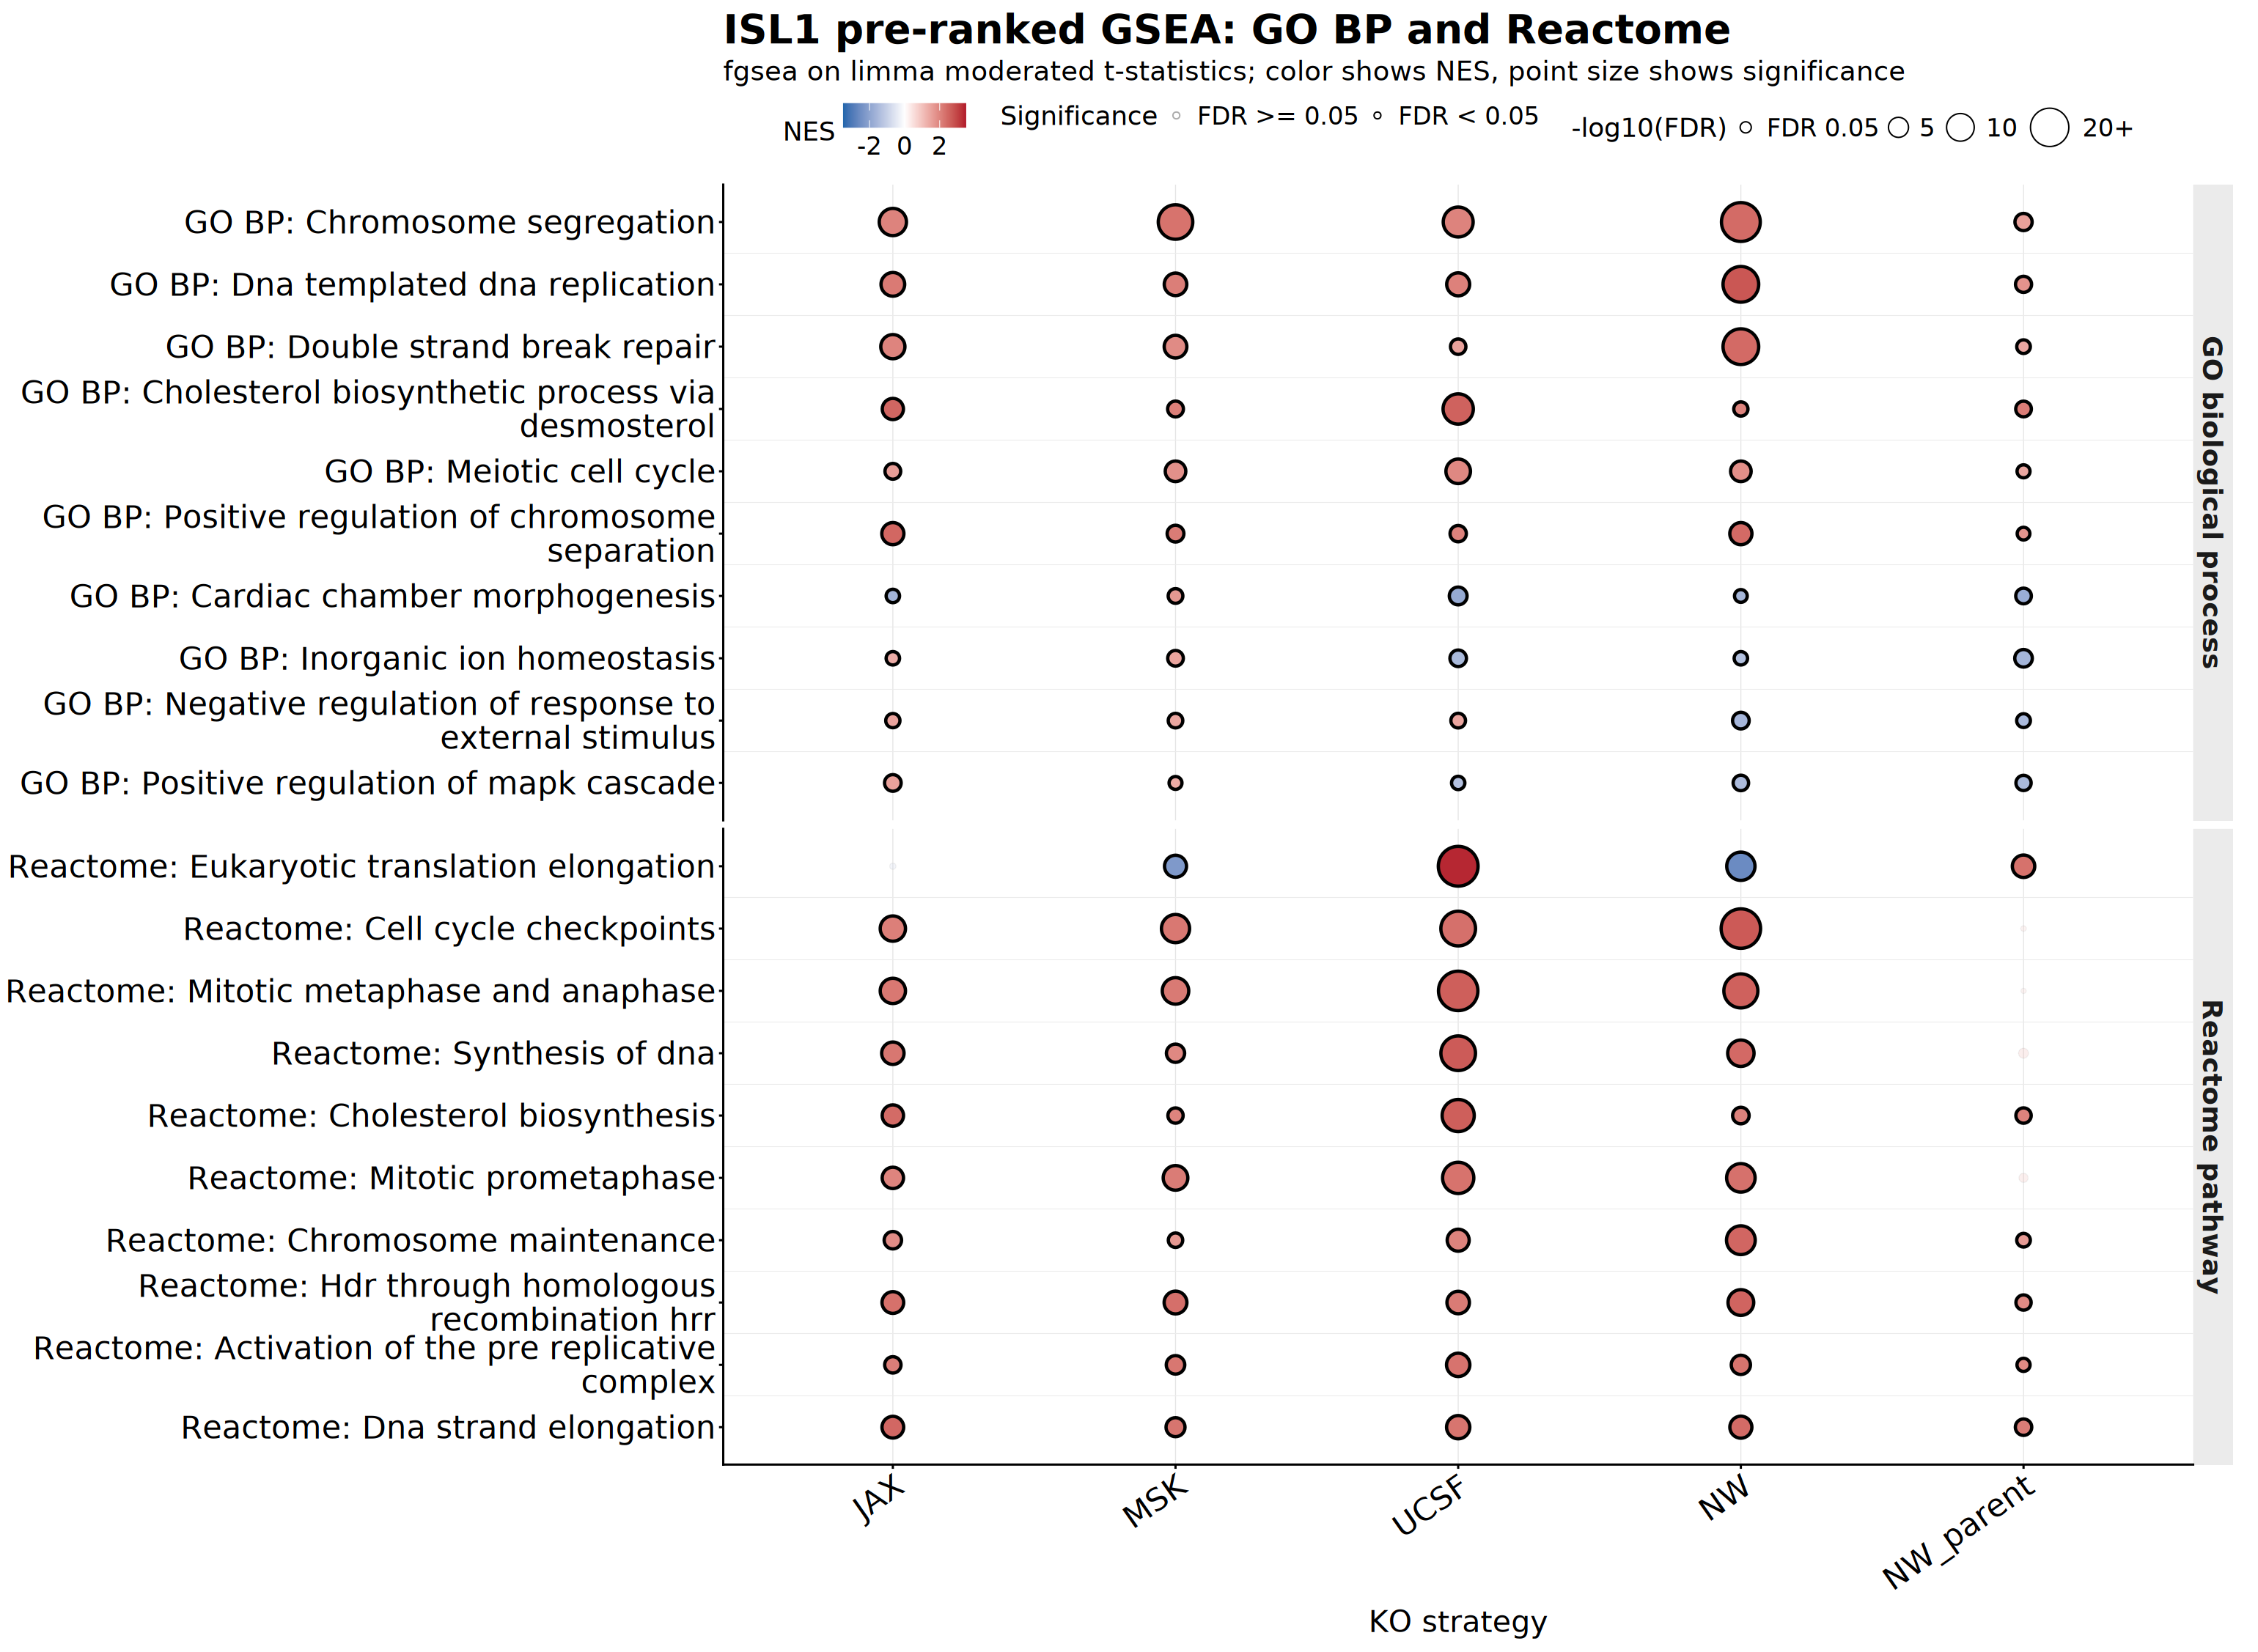

target_gene,figure,height
<chr>,<chr>,<dbl>
GCM1,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/gsea_dot_heatmaps/GCM1_fgsea_preranked_dot_heatmap.png,19.6
NKX2-1,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/gsea_dot_heatmaps/NKX2-1_fgsea_preranked_dot_heatmap.png,16.8
ISL1,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/gsea_dot_heatmaps/ISL1_fgsea_preranked_dot_heatmap.png,17.5
EOMES,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/gsea_dot_heatmaps/EOMES_fgsea_preranked_dot_heatmap.png,16.1


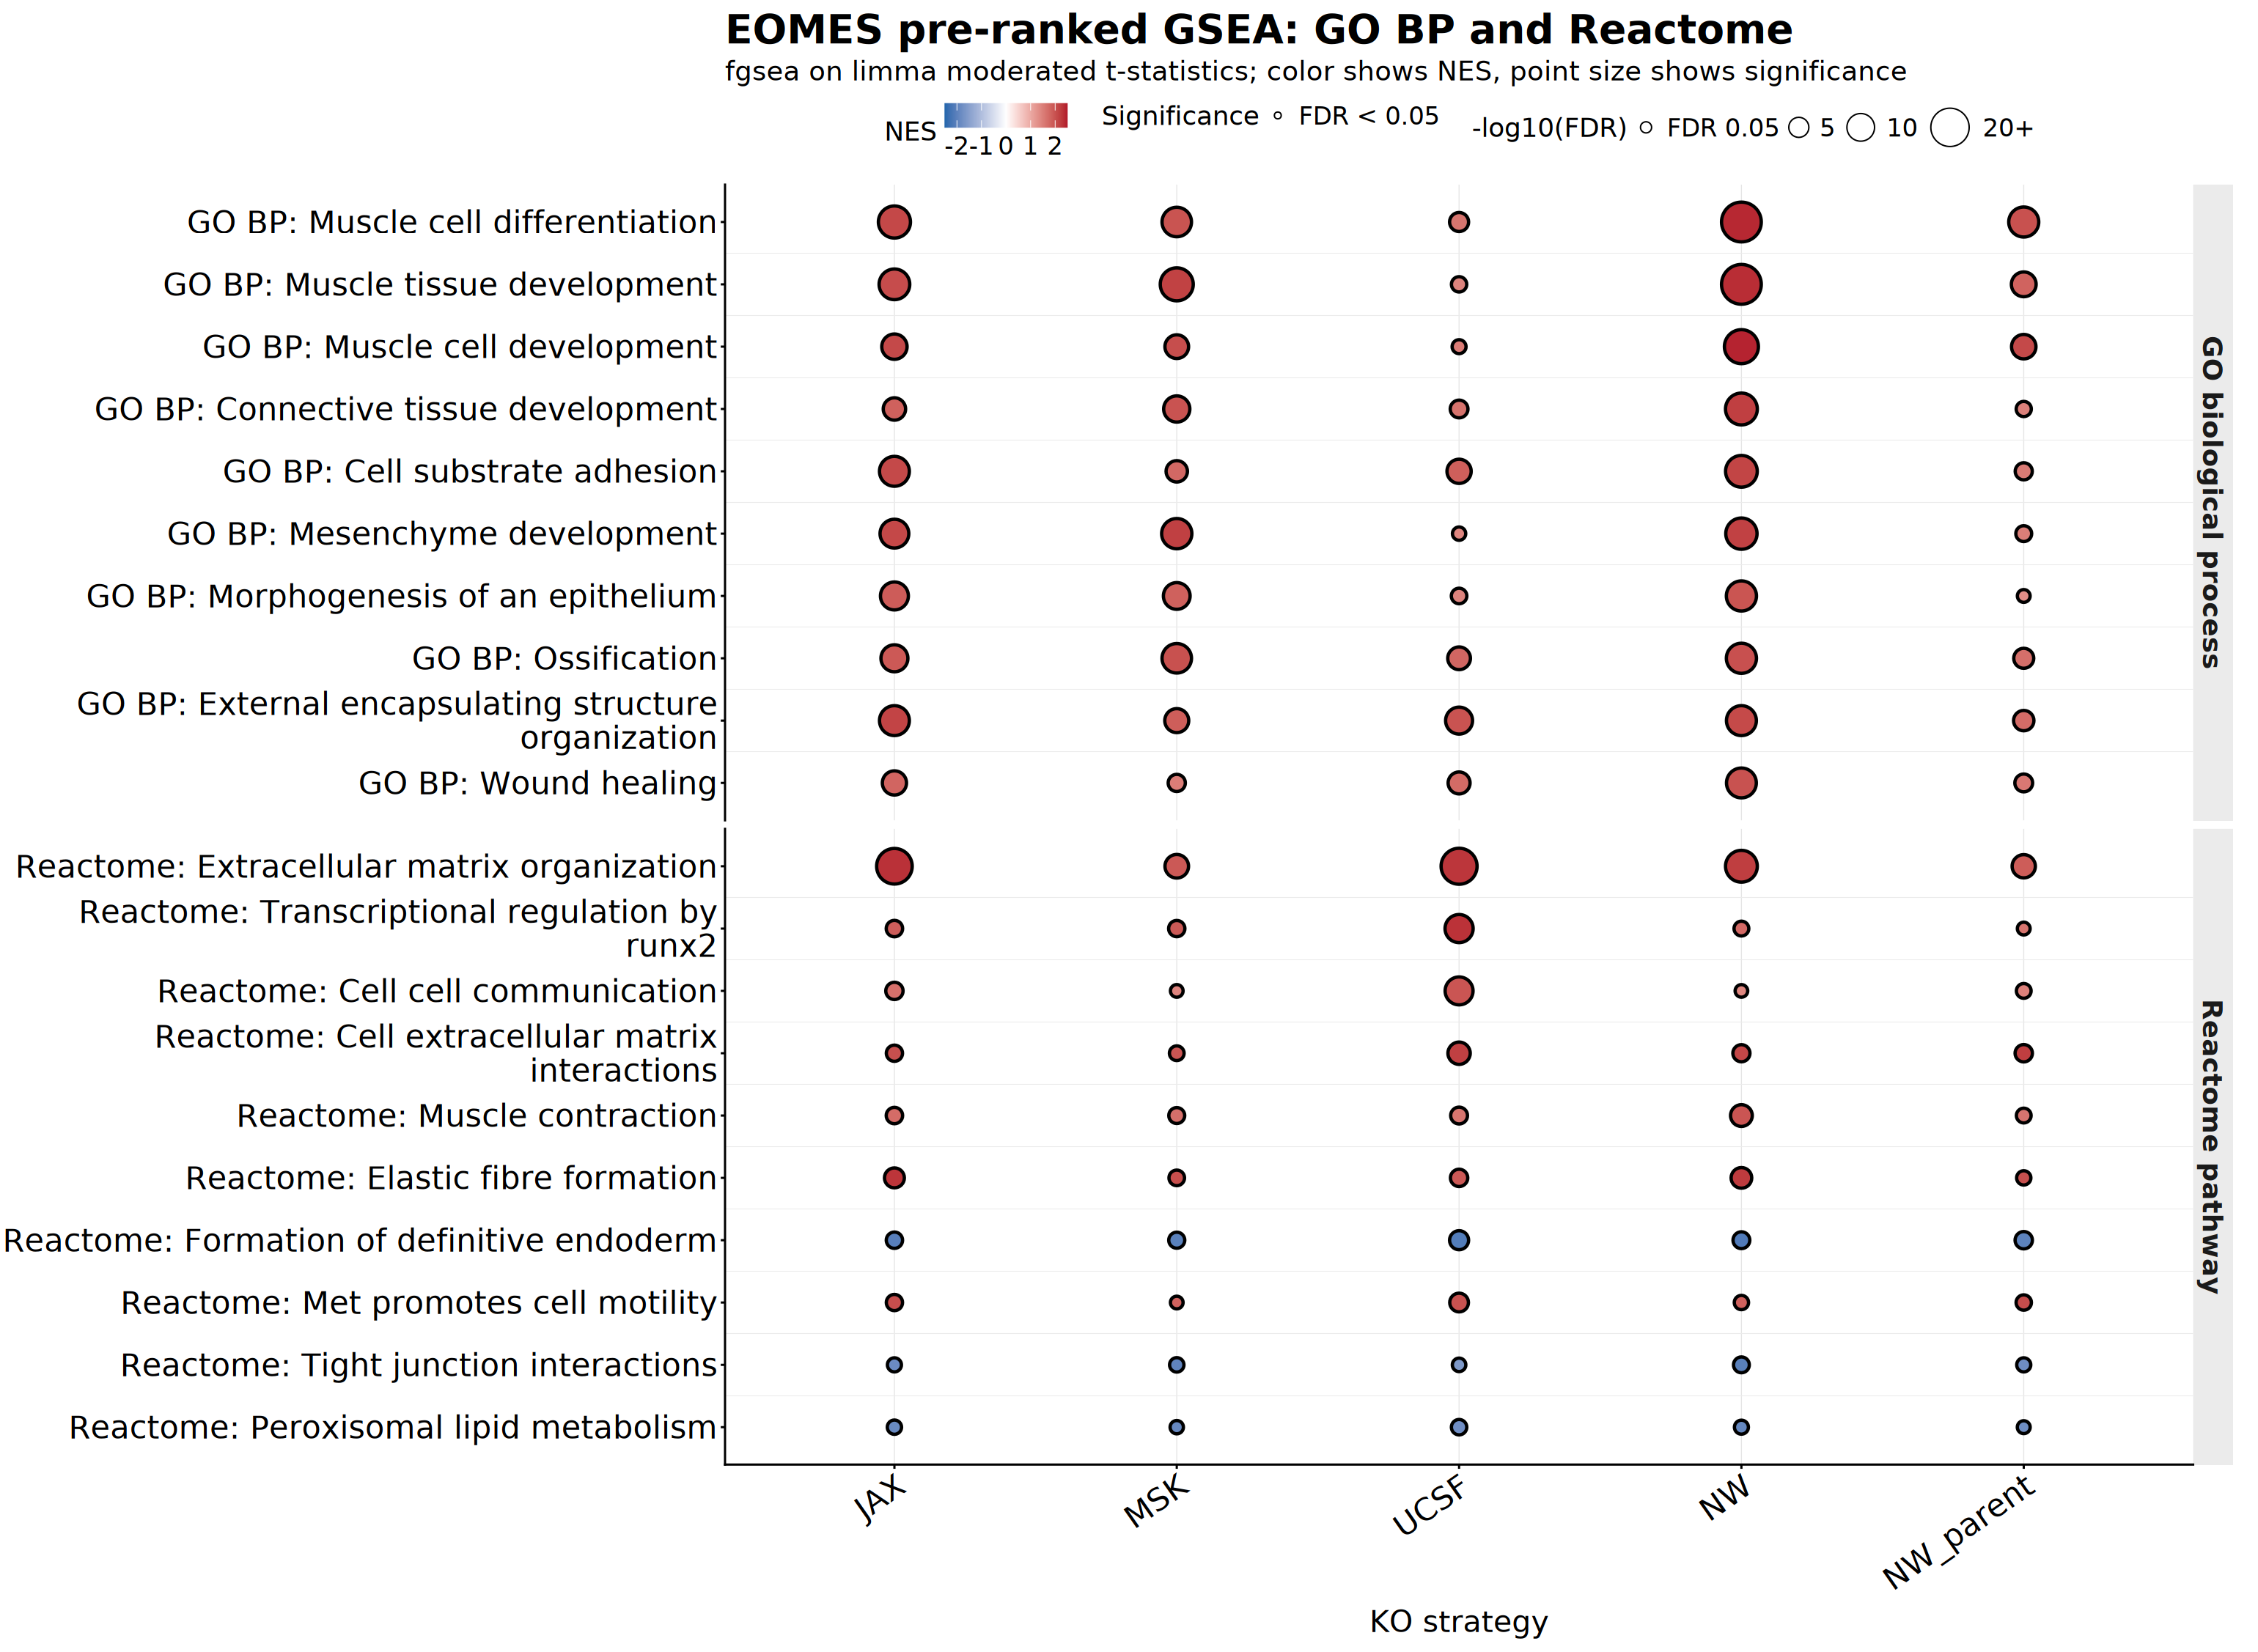

In [24]:
gsea_heatmap_top_terms_per_type <- 10
gsea_heatmap_candidate_terms_per_type <- 60
gsea_heatmap_min_genes_tested <- 15
gsea_heatmap_redundancy_jaccard_cutoff <- 0.45
gsea_score_cap <- 20
gsea_label_wrap_width <- 44
gsea_comparison_cohorts <- c("JAX", "MSK", "UCSF", "NW", "NW_parent", "NW_DMSO")
print_gsea_heatmaps <- TRUE

gsea_heatmap_dir <- file.path(figure_dir, "gsea_dot_heatmaps")
dir.create(gsea_heatmap_dir, recursive = TRUE, showWarnings = FALSE)

if (!exists("safe_name")) {
  safe_name <- function(x) {
    x %>%
      as.character() %>%
      str_replace_all("[^A-Za-z0-9_-]+", "_") %>%
      str_replace_all("_+", "_") %>%
      str_replace_all("^_|_$", "")
  }
}

if (!exists("type_label_short")) {
  type_label_short <- function(x) {
    recode(as.character(x), "GO biological process" = "GO BP", "Reactome pathway" = "Reactome")
  }
}

heatmap_term_gene_lookup <- gene_sets %>%
  group_by(type, category) %>%
  summarise(term_genes = list(unique(gene)), .groups = "drop")

filter_redundant_heatmap_terms <- function(term_rank, max_terms_per_type, jaccard_cutoff) {
  if (nrow(term_rank) == 0) {
    return(term_rank)
  }
  
  term_rank %>%
    left_join(heatmap_term_gene_lookup, by = c("type", "category")) %>%
    group_by(type) %>%
    group_modify(function(.x, .y) {
      keep <- rep(FALSE, nrow(.x))
      kept_genes <- list()
      
      for (i in seq_len(nrow(.x))) {
        genes_i <- .x$term_genes[[i]]
        if (is.null(genes_i) || length(genes_i) == 0 || all(is.na(genes_i))) {
          genes_i <- character()
        }
        
        too_similar <- any(vapply(kept_genes, function(genes_j) {
          union_n <- length(union(genes_i, genes_j))
          if (union_n == 0) {
            return(FALSE)
          }
          length(intersect(genes_i, genes_j)) / union_n >= jaccard_cutoff
        }, logical(1)))
        
        if (!too_similar) {
          keep[i] <- TRUE
          kept_genes[[length(kept_genes) + 1]] <- genes_i
        }
        
        if (sum(keep) >= max_terms_per_type) {
          break
        }
      }
      
      .x[keep, , drop = FALSE]
    }) %>%
    ungroup() %>%
    select(-term_genes)
}


select_gsea_heatmap_terms <- function(d) {
  ranked_terms <- d %>%
    filter(
      !is.na(FDR),
      !is.na(NES),
      !is.na(category_label),
      !is.na(n_genes_tested),
      n_genes_tested >= gsea_heatmap_min_genes_tested
    ) %>%
    mutate(
      neg_log10_fdr = -log10(pmax(FDR, .Machine$double.xmin)),
      abs_effect = abs(NES)
    ) %>%
    group_by(type, category, category_label) %>%
    summarise(
      n_sig_cohorts = sum(FDR < fdr_cutoff, na.rm = TRUE),
      best_FDR = min(FDR, na.rm = TRUE),
      best_score = max(neg_log10_fdr, na.rm = TRUE),
      max_abs_effect = max(abs_effect, na.rm = TRUE),
      max_n_genes_tested = max(n_genes_tested, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    group_by(type) %>%
    arrange(desc(n_sig_cohorts), best_FDR, desc(max_abs_effect), desc(max_n_genes_tested), .by_group = TRUE) %>%
    slice_head(n = gsea_heatmap_candidate_terms_per_type) %>%
    ungroup()
  
  filter_redundant_heatmap_terms(
    ranked_terms,
    max_terms_per_type = gsea_heatmap_top_terms_per_type,
    jaccard_cutoff = gsea_heatmap_redundancy_jaccard_cutoff
  ) %>%
    arrange(type, best_FDR, desc(max_abs_effect))
}


make_gsea_heatmap_data <- function(gene1) {
  available_cohorts <- gsea_comparison_cohorts[
    gsea_comparison_cohorts %in% as.character(gsea_results$cohort)
  ]
  
  d <- gsea_results %>%
    filter(
      as.character(target_gene) == gene1,
      as.character(cohort) %in% available_cohorts
    ) %>%
    mutate(
      target_gene = as.character(target_gene),
      cohort = factor(as.character(cohort), levels = available_cohorts, ordered = TRUE),
      type = as.character(type),
      term_id = paste(type, category, sep = "___"),
      term_label = paste0(type_label_short(type), ": ", category_label)
    )
  
  selected_terms <- select_gsea_heatmap_terms(d) %>%
    mutate(
      type = as.character(type),
      term_id = paste(type, category, sep = "___"),
      term_label = paste0(type_label_short(type), ": ", category_label),
      term_label_wrapped = str_wrap(term_label, width = gsea_label_wrap_width)
    )
  
  if (nrow(selected_terms) == 0) {
    return(tibble())
  }
  
  term_levels <- rev(selected_terms$term_id)
  term_labels <- setNames(selected_terms$term_label_wrapped, selected_terms$term_id)
  
  d %>%
    semi_join(selected_terms %>% select(term_id), by = "term_id") %>%
    mutate(
      term_id = factor(term_id, levels = term_levels),
      term_label_wrapped = term_labels[as.character(term_id)],
      neg_log10_fdr = -log10(pmax(FDR, .Machine$double.xmin)),
      neg_log10_fdr_plot = pmin(neg_log10_fdr, gsea_score_cap),
      is_significant_term = FDR < fdr_cutoff,
      type = factor(type, levels = c("GO biological process", "Reactome pathway"))
    )
}

make_gsea_heatmap <- function(gene1) {
  plot_df <- make_gsea_heatmap_data(gene1)
  if (nrow(plot_df) == 0) {
    return(NULL)
  }
  
  term_label_stats <- plot_df %>%
    distinct(term_id, term_label_wrapped) %>%
    mutate(label_lines = str_count(term_label_wrapped, fixed("\n")) + 1)
  
  term_label_lookup <- term_label_stats %>%
    select(term_id, term_label_wrapped) %>%
    tibble::deframe()
  
  n_terms <- n_distinct(plot_df$term_id)
  label_height_units <- sum(term_label_stats$label_lines, na.rm = TRUE)
  display_width <- 22
  display_height <- max(12, 0.7 * label_height_units)
  plot_width <- display_width
  plot_height <- display_height
  nes_limit <- max(abs(plot_df$NES), na.rm = TRUE)
  if (!is.finite(nes_limit) || nes_limit == 0) {
    nes_limit <- 1
  }
  nes_limit <- max(2, ceiling(nes_limit * 2) / 2)
  
  hline_df <- plot_df %>%
    distinct(type, term_id) %>%
    count(type, name = "n_terms_type") %>%
    mutate(yintercept = purrr::map(n_terms_type, ~ if (.x > 1) seq(1.5, .x - 0.5, by = 1) else numeric())) %>%
    tidyr::unnest(yintercept)
  
  ggplot(plot_df, aes(x = cohort, y = term_id)) +
    geom_point(
      aes(
        size = neg_log10_fdr_plot,
        fill = NES,
        alpha = is_significant_term,
        color = is_significant_term,
        stroke = is_significant_term
      ),
      shape = 21
    ) +
    geom_hline(
      data = hline_df,
      aes(yintercept = yintercept),
      inherit.aes = FALSE,
      color = "grey92",
      linewidth = 0.2
    ) +
    scale_y_discrete(labels = term_label_lookup, drop = TRUE) +
    scale_fill_gradient2(
      low = "#2166AC",
      mid = "white",
      high = "#B2182B",
      midpoint = 0,
      limits = c(-nes_limit, nes_limit),
      name = "NES"
    ) +
    scale_size_area(
      max_size = 12,
      limits = c(0, gsea_score_cap),
      breaks = c(-log10(fdr_cutoff), 5, 10, 20),
      labels = c("FDR 0.05", "5", "10", paste0(gsea_score_cap, "+")),
      name = "-log10(FDR)"
    ) +
    scale_color_manual(
      values = c(`TRUE` = "black", `FALSE` = "grey68"),
      labels = c(`TRUE` = "FDR < 0.05", `FALSE` = "FDR >= 0.05"),
      name = "Significance"
    ) +
    scale_discrete_manual(
      aesthetics = "stroke",
      values = c(`TRUE` = 1.25, `FALSE` = 0.35),
      guide = "none"
    ) +
    scale_alpha_manual(values = c(`TRUE` = 1, `FALSE` = 0.18), guide = "none") +
    facet_grid(type ~ ., scales = "free_y", space = "free_y") +
    labs(
      x = "KO strategy",
      y = NULL,
      title = paste0(gene1, " pre-ranked GSEA: GO BP and Reactome"),
      subtitle = "fgsea on limma moderated t-statistics; color shows NES, point size shows significance"
    ) +
    theme(
      legend.position = "top",
      text = element_text(size = 20),
      axis.text.x = element_text(size = 22, angle = 35, hjust = 1),
      axis.text.y = element_text(size = 22, lineheight = 0.9),
      axis.title.x = element_text(size = 21, margin = margin(t = 10)),
      legend.title = element_text(size = 18),
      legend.text = element_text(size = 17),
      strip.text.y = element_text(size = 19, face = "bold"),
      strip.background = element_rect(fill = "grey92", color = NA),
      panel.grid.major.x = element_line(color = "grey90", linewidth = 0.25),
      panel.grid.major.y = element_blank(),
      panel.grid.minor = element_blank(),
      plot.title = element_text(face = "bold", size = 28),
      plot.subtitle = element_text(size = 19),
      plot.margin = margin(10, 18, 10, 10)
    ) -> p
  
  attr(p, "plot_width") <- plot_width
  attr(p, "plot_height") <- plot_height
  attr(p, "display_width") <- display_width
  attr(p, "display_height") <- display_height
  p
}

gsea_heatmap_index <- tibble()

if (!exists("gsea_results") || nrow(gsea_results) == 0) {
  warning("No pre-ranked GSEA results are available. Run the GSEA cell first and check that fgsea is installed.")
} else {
  for (gene1 in target_genes) {
    p <- make_gsea_heatmap(gene1)
    if (is.null(p)) {
      next
    }
    
    out_file <- file.path(gsea_heatmap_dir, paste0(safe_name(gene1), "_fgsea_preranked_dot_heatmap.png"))
    plot_width <- attr(p, "plot_width")
    plot_height <- attr(p, "plot_height")
    
    if (print_gsea_heatmaps) {
      display_width <- attr(p, "display_width")
      display_height <- attr(p, "display_height")
      set_notebook_plot_size(width = display_width, height = display_height, res = 140, pointsize = 18)
      print(p)
    }
    
    ggsave(
      out_file,
      plot = p,
      width = plot_width,
      height = plot_height,
      device = "png",
      dpi = 300,
      bg = "transparent",
      limitsize = FALSE
    )
    
    gsea_heatmap_index <- bind_rows(
      gsea_heatmap_index,
      tibble(target_gene = gene1, figure = out_file, height = plot_height)
    )
  }
  
  data.table::fwrite(gsea_heatmap_index, file.path(figure_dir, "DE_fgsea_preranked_heatmap_index.tsv"), sep = "\t")
}

gsea_heatmap_index


In [25]:
gene_set_summary %>%
  arrange(target_gene, cohort, type)

gene_set_results %>%
  filter(FDR < fdr_cutoff) %>%
  arrange(target_gene, cohort, type, FDR) %>%
  select(target_gene, cohort, type, category_label, direction, FDR, mean_logFC, n_genes_tested) %>%
  group_by(target_gene, cohort, type) %>%
  slice_head(n = 10) %>%
  ungroup()

gene_set_heatmap_index


target_gene,cohort,type,n_terms,n_sig_terms,top_category,top_FDR
<fct>,<ord>,<fct>,<int>,<int>,<chr>,<dbl>
GCM1,JAX,GO biological process,4891,240,Vascular associated smooth muscle cell development,1.313236e-06
GCM1,JAX,Reactome pathway,1376,218,Tfap2 ap 2 family regulates transcription of growth factors and their receptors,1.845933e-13
GCM1,MSK,GO biological process,4891,214,Cytoplasmic translation,1.714300e-06
GCM1,MSK,Reactome pathway,1376,182,Srp dependent cotranslational protein targeting to membrane,1.809359e-12
GCM1,UCSF,GO biological process,4926,704,Negative regulation of alpha beta t cell proliferation,3.043368e-13
GCM1,UCSF,Reactome pathway,1390,253,Tfap2 ap 2 family regulates transcription of growth factors and their receptors,2.264880e-17
GCM1,NW,GO biological process,4926,56,Cytoplasmic translation,3.817860e-09
GCM1,NW,Reactome pathway,1390,208,Eukaryotic translation initiation,7.228363e-13
GCM1,NW_parent,GO biological process,4909,202,Cytoplasmic translation,1.106678e-10


target_gene,cohort,type,category_label,direction,FDR,mean_logFC,n_genes_tested
<fct>,<ord>,<fct>,<chr>,<fct>,<dbl>,<dbl>,<int>
GCM1,JAX,GO biological process,Vascular associated smooth muscle cell development,down,1.313236e-06,-1.2270017,10
GCM1,JAX,GO biological process,Cytoplasmic translation,down,1.368143e-05,-0.3656808,171
GCM1,JAX,GO biological process,Post translational protein targeting to membrane translocation,down,1.549201e-05,-0.8685010,11
GCM1,JAX,GO biological process,Protein folding in endoplasmic reticulum,down,1.641597e-05,-0.8505069,12
GCM1,JAX,GO biological process,Negative regulation of alpha beta t cell proliferation,down,2.063527e-05,-1.7501064,10
GCM1,JAX,GO biological process,Post translational protein targeting to endoplasmic reticulum membrane,down,2.562172e-05,-0.6537037,19
GCM1,JAX,GO biological process,Angiogenesis involved in wound healing,down,3.501457e-05,-1.0808823,27
GCM1,JAX,GO biological process,Cell migration involved in sprouting angiogenesis,down,6.446500e-05,-0.6485302,56
GCM1,JAX,GO biological process,Formation of cytoplasmic translation initiation complex,down,9.736922e-05,-0.6846361,15


target_gene,figure,height
<chr>,<chr>,<dbl>
GCM1,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/gene_set_dot_heatmaps/GCM1_gene_set_dot_heatmap.png,23.8
NKX2-1,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/gene_set_dot_heatmaps/NKX2-1_gene_set_dot_heatmap.png,21.7
ISL1,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/gene_set_dot_heatmaps/ISL1_gene_set_dot_heatmap.png,18.9
EOMES,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/gene_set_dot_heatmaps/EOMES_gene_set_dot_heatmap.png,16.8


## Significant DE gene counts

target_gene,cohort,n_genes,n_sig,n_up,n_down,min_adj_p,median_abs_logFC
<fct>,<ord>,<int>,<int>,<int>,<int>,<dbl>,<dbl>
GCM1,JAX,21366,4899,1791,3108,7.757280e-15,0.6092781
GCM1,MSK,21366,4310,1347,2963,9.263222e-13,0.5759793
GCM1,UCSF,21644,6885,2642,4243,7.736036e-31,0.6900721
GCM1,NW,21644,1995,610,1385,2.668292e-08,0.3548824
GCM1,NW_parent,21435,3376,1242,2134,3.021979e-12,0.4712306
NKX2-1,JAX,22730,1340,864,476,4.069490e-09,0.3518032
NKX2-1,MSK,22655,3178,1657,1521,1.073486e-10,0.5921024
NKX2-1,UCSF,22866,724,491,233,1.660852e-09,0.3002070
NKX2-1,NW,22842,25,19,6,9.775392e-05,0.2142493


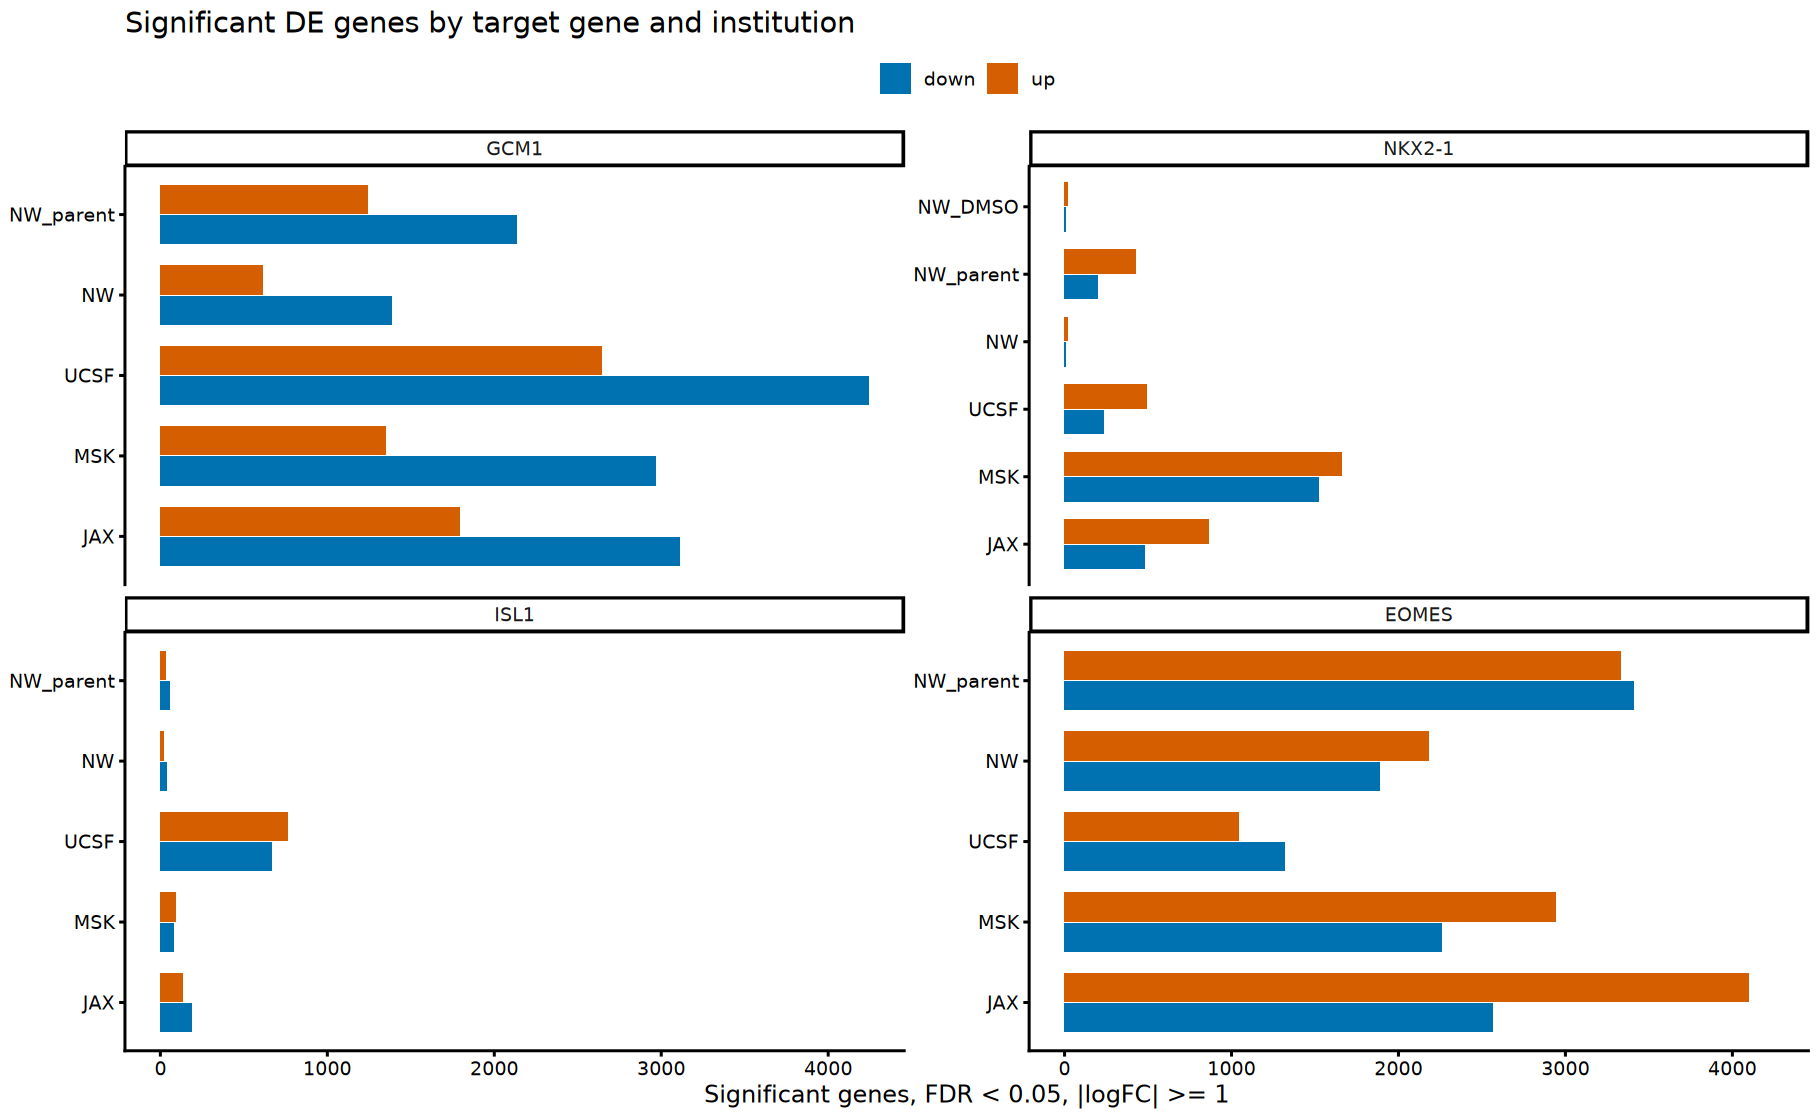

In [26]:
summary_counts <- de_results %>%
  group_by(target_gene, cohort) %>%
  summarise(
    n_genes = n(),
    n_sig = sum(is_significant, na.rm = TRUE),
    n_up = sum(direction == "up", na.rm = TRUE),
    n_down = sum(direction == "down", na.rm = TRUE),
    min_adj_p = min(adj.P.Val, na.rm = TRUE),
    median_abs_logFC = median(abs(logFC), na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(target_gene, cohort)

summary_counts

sig_counts_long <- summary_counts %>%
  select(target_gene, cohort, n_up, n_down) %>%
  pivot_longer(c(n_up, n_down), names_to = "direction", values_to = "n") %>%
  mutate(direction = recode(direction, n_up = "up", n_down = "down"))

sig_count_plot <- ggplot(sig_counts_long, aes(x = cohort, y = n, fill = direction)) +
  geom_col(position = position_dodge(width = 0.75), width = 0.7) +
  facet_wrap(~ target_gene, ncol = 2, scales = "free_y") +
  coord_flip() +
  scale_fill_manual(values = c(down = "#0072B2", up = "#D55E00")) +
  labs(
    x = NULL,
    y = paste0("Significant genes, FDR < ", fdr_cutoff, ", |logFC| >= ", logfc_cutoff),
    fill = NULL,
    title = "Significant DE genes by target gene and institution"
  ) +
  theme(legend.position = "top")

set_notebook_plot_size(width = 13, height = 8, res = 140, pointsize = 12)
print(sig_count_plot)
set_notebook_plot_size()

ggsave(
  file.path(figure_dir, "DE_significant_gene_counts.png"),
  plot = sig_count_plot,
  width = 9,
  height = 6,
  device = "png", dpi = 300,
  bg = "transparent"
)

## Combined volcano plot

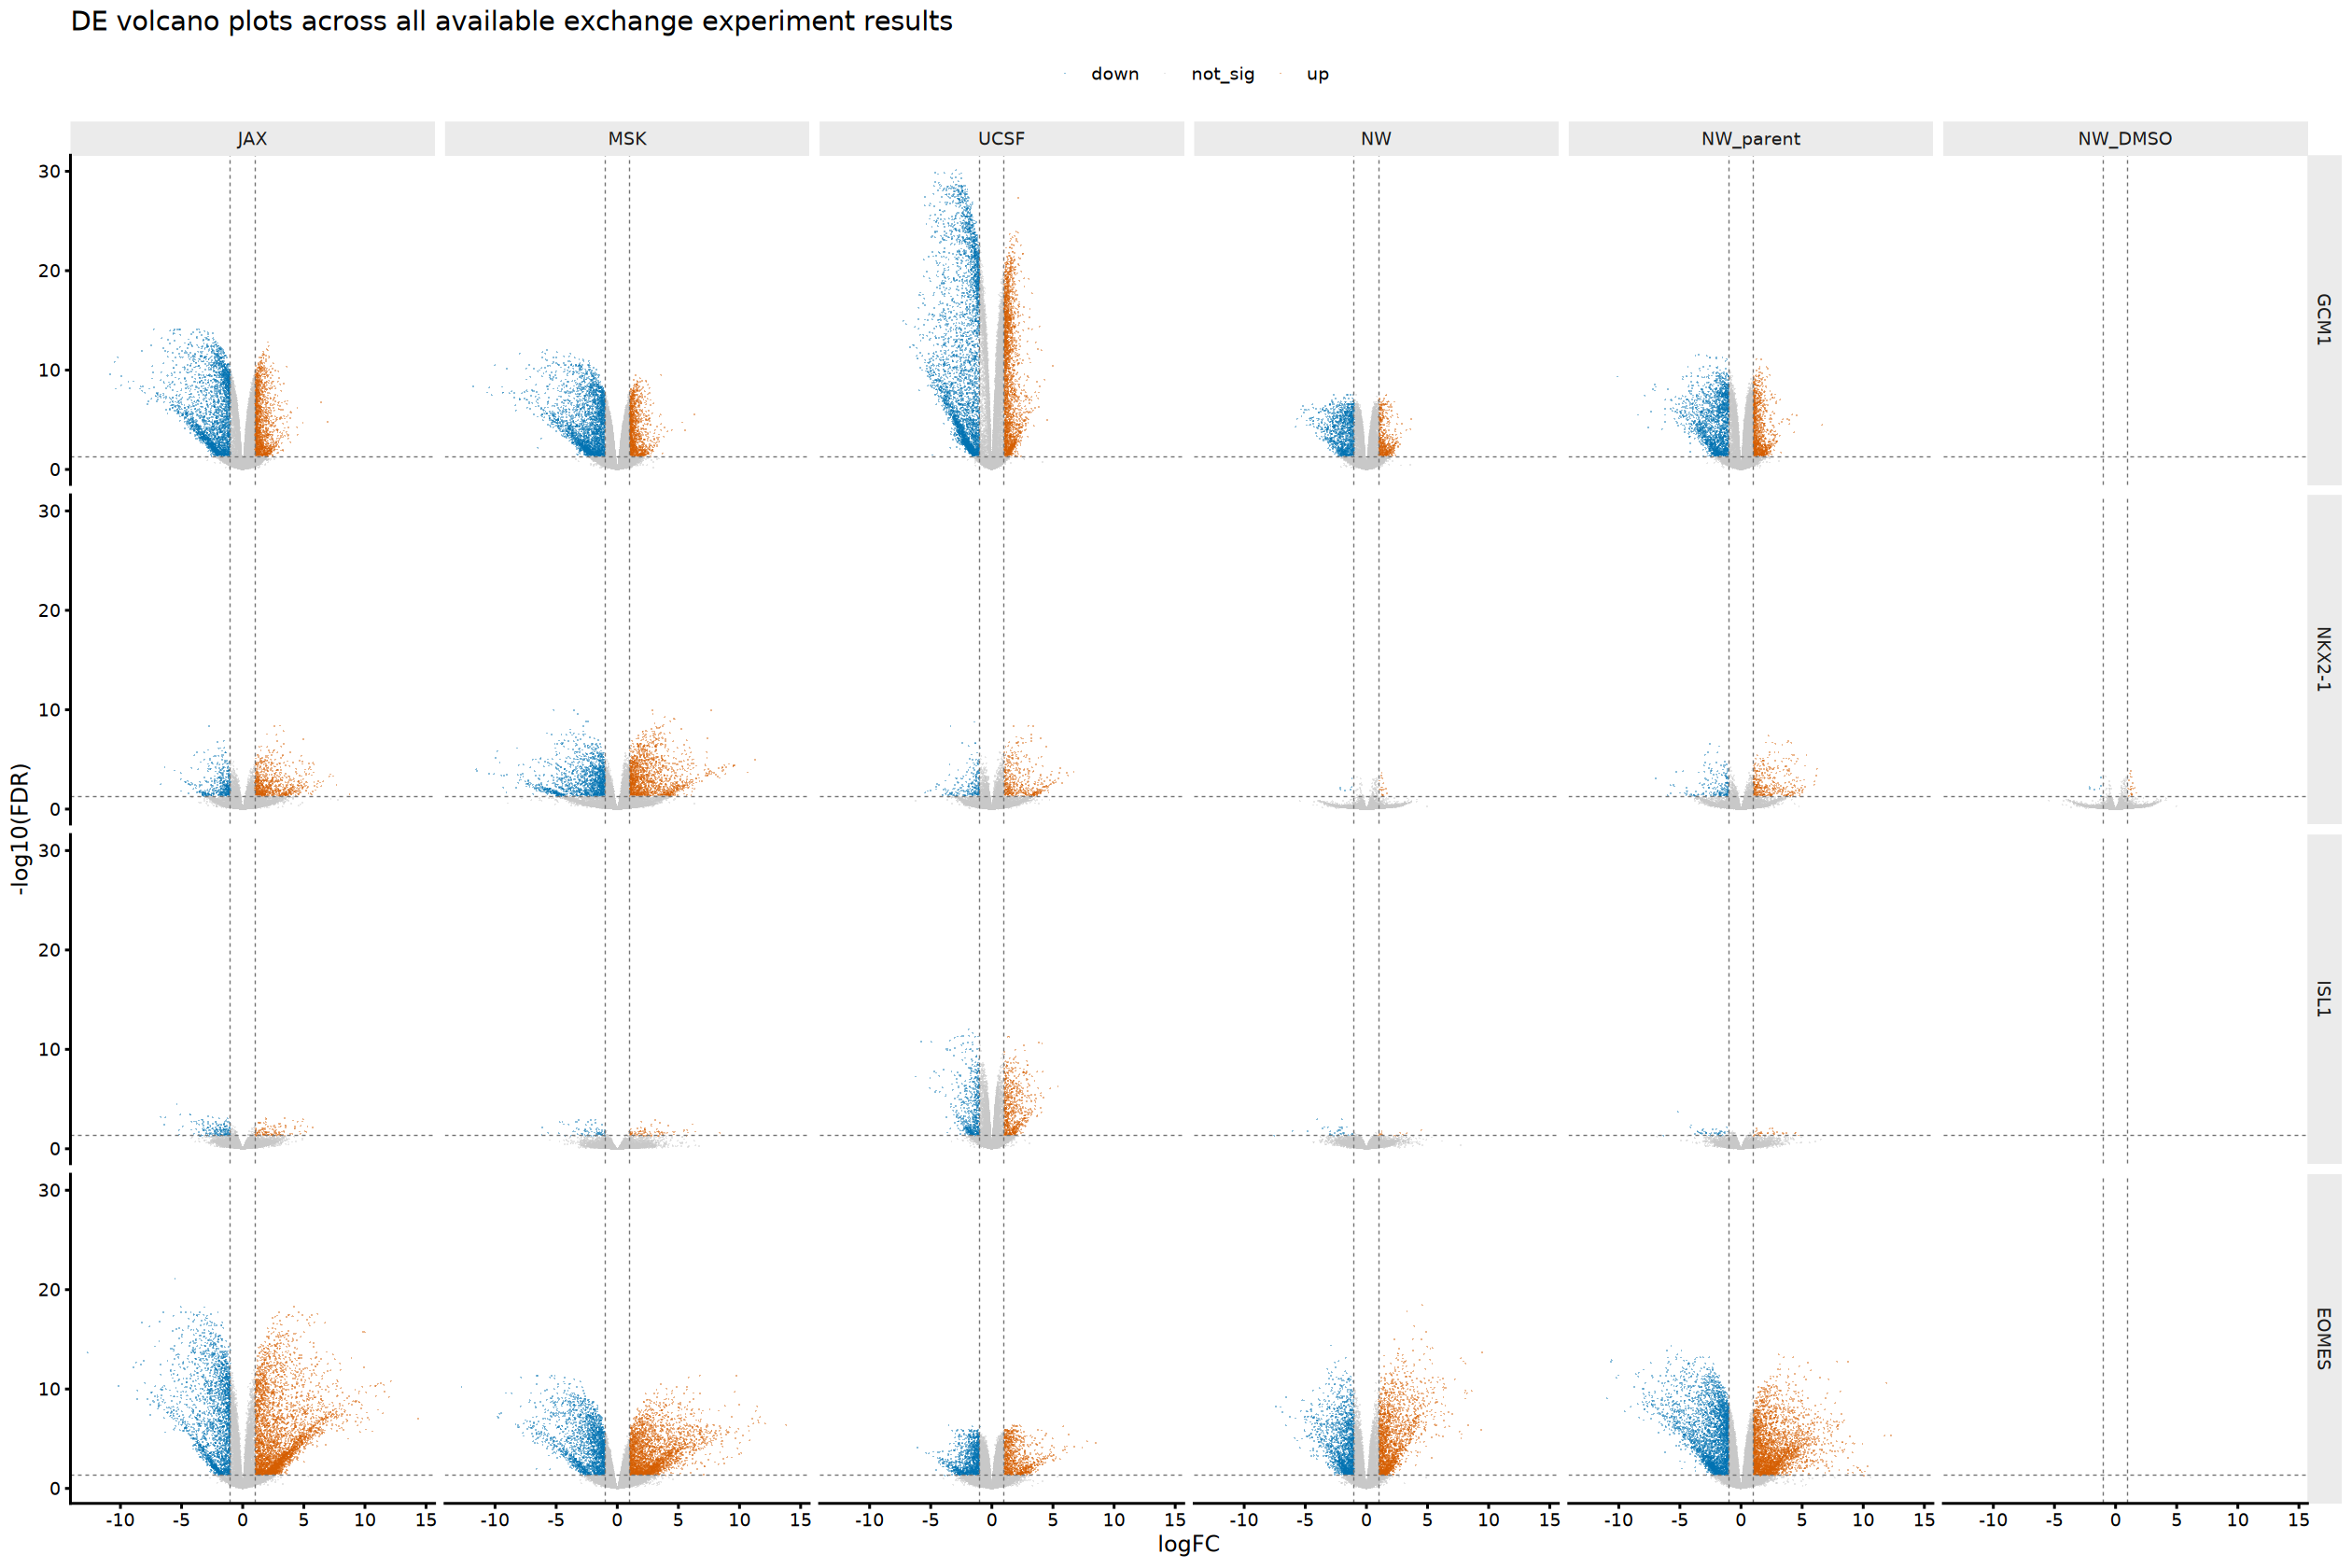

In [27]:
volcano_colors <- c(down = "#0072B2", not_sig = "grey78", up = "#D55E00")

combined_volcano <- ggplot(de_results, aes(x = logFC, y = neg_log10_adj_p, color = direction)) +
  geom_point(size = 0.25, alpha = 0.45, stroke = 0) +
  geom_vline(xintercept = c(-logfc_cutoff, logfc_cutoff), linetype = "dashed", linewidth = 0.25, color = "grey45") +
  geom_hline(yintercept = -log10(fdr_cutoff), linetype = "dashed", linewidth = 0.25, color = "grey45") +
  facet_grid(target_gene ~ cohort) +
  scale_color_manual(values = volcano_colors, drop = FALSE) +
  labs(
    x = "logFC",
    y = "-log10(FDR)",
    color = NULL,
    title = "DE volcano plots across all available exchange experiment results"
  ) +
  theme(
    legend.position = "top",
    strip.background = element_rect(fill = "grey92", color = NA),
    panel.spacing = unit(0.4, "lines")
  )

set_notebook_plot_size(width = 18, height = 12, res = 140, pointsize = 12)
print(combined_volcano)
set_notebook_plot_size()

ggsave(
  file.path(figure_dir, "DE_combined_volcano.png"),
  plot = combined_volcano,
  width = 14,
  height = 9,
  device = "png", dpi = 300,
  bg = "transparent"
)

## Highlight selected genes in volcano plots

In [28]:
volcano_highlight_genes <- tibble::tribble(
  ~target_gene, ~query_gene, ~canonical_gene,
  "EOMES", "SOX17", "SOX17",
  "GCM1", "PGF", "PGF",
  "GCM1", "pRR9", "PRR9",
  "GCM1", "TWIST2", "TWIST2",
  "GCM1", "LMO2", "LMO2"
) %>%
  mutate(
    target_gene = as.character(target_gene),
    gene_key = str_to_upper(canonical_gene)
  )

highlighted_volcano_dir <- file.path(figure_dir, "highlighted_volcano_plots")
dir.create(highlighted_volcano_dir, recursive = TRUE, showWarnings = FALSE)

png_device <- if (requireNamespace("ragg", quietly = TRUE)) ragg::agg_png else "png"
volcano_width_px <- 1920
volcano_height_px <- round(volcano_width_px * 3 / 4)

volcano_title <- function(target_gene, cohort) {
  cohort <- as.character(cohort)
  if (cohort == "UCSF") {
    "Volcano Plot: KO DOX vs DMSO for UCSF"
  } else if (cohort == "NW") {
    "Volcano Plot: KO IAA vs DMSO for NW"
  } else if (cohort == "NW_parent") {
    if (target_gene == "GCM1") "Volcano Plot: KO IAA vs Parents for NW" else "Volcano Plot: KO IAA vs DMSO for NW Parent"
  } else if (cohort == "NW_DMSO") {
    "Volcano Plot: KO IAA vs DMSO for NW"
  } else if (cohort == "JAX") {
    "Volcano Plot: KO JAX vs WT"
  } else if (cohort == "MSK") {
    "Volcano Plot: KO MSK vs WT"
  } else {
    paste0("Volcano Plot: ", target_gene, " ", cohort)
  }
}

make_highlighted_volcano_plot <- function(d) {
  target_gene1 <- as.character(unique(d$target_gene))
  cohort1 <- as.character(unique(d$cohort))
  
  d1 <- d %>%
    mutate(
      threshold = adj.P.Val < fdr_cutoff & abs(logFC) > logfc_cutoff,
      neglog10p = -log10(pmax(adj.P.Val, .Machine$double.xmin)),
      gene_key = str_to_upper(gene_symbol)
    )
  
  label_df <- d1 %>%
    inner_join(volcano_highlight_genes, by = c("target_gene", "gene_key")) %>%
    mutate(label = query_gene) %>%
    arrange(adj.P.Val)
  
  ggplot(d1, aes(x = logFC, y = neglog10p)) +
    geom_point(aes(color = threshold), alpha = 0.6, size = 1.5) +
    geom_point(
      data = label_df,
      aes(x = logFC, y = neglog10p),
      inherit.aes = FALSE,
      shape = 21,
      fill = "#F0E442",
      color = "black",
      size = 3.2,
      stroke = 0.8
    ) +
    ggrepel::geom_text_repel(
      data = label_df,
      aes(x = logFC, y = neglog10p, label = label),
      inherit.aes = FALSE,
      size = 3.4,
      max.overlaps = Inf,
      box.padding = 0.35,
      point.padding = 0.25,
      min.segment.length = 0,
      segment.alpha = 0.7,
      seed = 1
    ) +
    scale_color_manual(values = c("FALSE" = "grey70", "TRUE" = "red"), guide = "none") +
    theme_minimal(base_size = 14) +
    labs(
      title = volcano_title(target_gene1, cohort1),
      x = "log2 Fold Change",
      y = "-log10(adjusted p-value)"
    ) +
    geom_vline(xintercept = c(-logfc_cutoff, logfc_cutoff), linetype = "dashed", color = "black") +
    geom_hline(yintercept = -log10(fdr_cutoff), linetype = "dashed", color = "black")
}

highlighted_volcano_index <- tibble()

highlighted_dataset_ids <- de_results %>%
  mutate(target_gene = as.character(target_gene), dataset_id = as.character(dataset_id)) %>%
  filter(target_gene %in% unique(volcano_highlight_genes$target_gene)) %>%
  distinct(dataset_id) %>%
  pull(dataset_id)

for (id in highlighted_dataset_ids) {
  d <- de_results %>%
    mutate(target_gene = as.character(target_gene), cohort = as.character(cohort), dataset_id = as.character(dataset_id)) %>%
    filter(dataset_id == id)
  p <- make_highlighted_volcano_plot(d)
  target_gene1 <- as.character(unique(d$target_gene))
  cohort1 <- as.character(unique(d$cohort))
  out_file <- file.path(
    highlighted_volcano_dir,
    paste0(target_gene1, "_VolcanoPlot_", cohort1, "_highlighted.png")
  )
  
  ggsave(
    filename = out_file,
    plot = p,
    device = png_device,
    bg = "transparent",
    width = volcano_width_px,
    height = volcano_height_px,
    units = "px",
    dpi = 300
  )
  
  highlighted_volcano_index <- bind_rows(
    highlighted_volcano_index,
    tibble(
      target_gene = target_gene1,
      cohort = cohort1,
      figure = out_file,
      n_highlighted = nrow(
        d %>%
          mutate(gene_key = str_to_upper(gene_symbol)) %>%
          inner_join(volcano_highlight_genes, by = c("target_gene", "gene_key"))
      )
    )
  )
}

highlighted_volcano_index


target_gene,cohort,figure,n_highlighted
<chr>,<chr>,<chr>,<int>
GCM1,JAX,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/highlighted_volcano_plots/GCM1_VolcanoPlot_JAX_highlighted.png,3
GCM1,MSK,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/highlighted_volcano_plots/GCM1_VolcanoPlot_MSK_highlighted.png,3
GCM1,UCSF,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/highlighted_volcano_plots/GCM1_VolcanoPlot_UCSF_highlighted.png,4
GCM1,NW,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/highlighted_volcano_plots/GCM1_VolcanoPlot_NW_highlighted.png,4
GCM1,NW_parent,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/highlighted_volcano_plots/GCM1_VolcanoPlot_NW_parent_highlighted.png,4
EOMES,JAX,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/highlighted_volcano_plots/EOMES_VolcanoPlot_JAX_highlighted.png,1
EOMES,MSK,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/highlighted_volcano_plots/EOMES_VolcanoPlot_MSK_highlighted.png,1
EOMES,UCSF,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/highlighted_volcano_plots/EOMES_VolcanoPlot_UCSF_highlighted.png,1
EOMES,NW,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/highlighted_volcano_plots/EOMES_VolcanoPlot_NW_highlighted.png,1


## DE gene overlap across core sites

Warning message in data.table::fread(file, data.table = FALSE):
“Detected 6 column names but the data has 7 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in data.table::fread(file, data.table = FALSE):
“Detected 6 column names but the data has 7 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in data.table::fread(file, data.table = FALSE):
“Detected 6 column names but the data has 7 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() af

target_gene,cohort,n_tested_genes,n_de_genes
<fct>,<ord>,<int>,<int>
GCM1,JAX,21366,4899
GCM1,MSK,21366,4310
GCM1,UCSF,21644,6885
GCM1,NW,21644,1995
GCM1,NW_parent,21435,3376
NKX2-1,JAX,22730,1340
NKX2-1,MSK,22655,3178
NKX2-1,UCSF,22866,724
NKX2-1,NW,22842,25


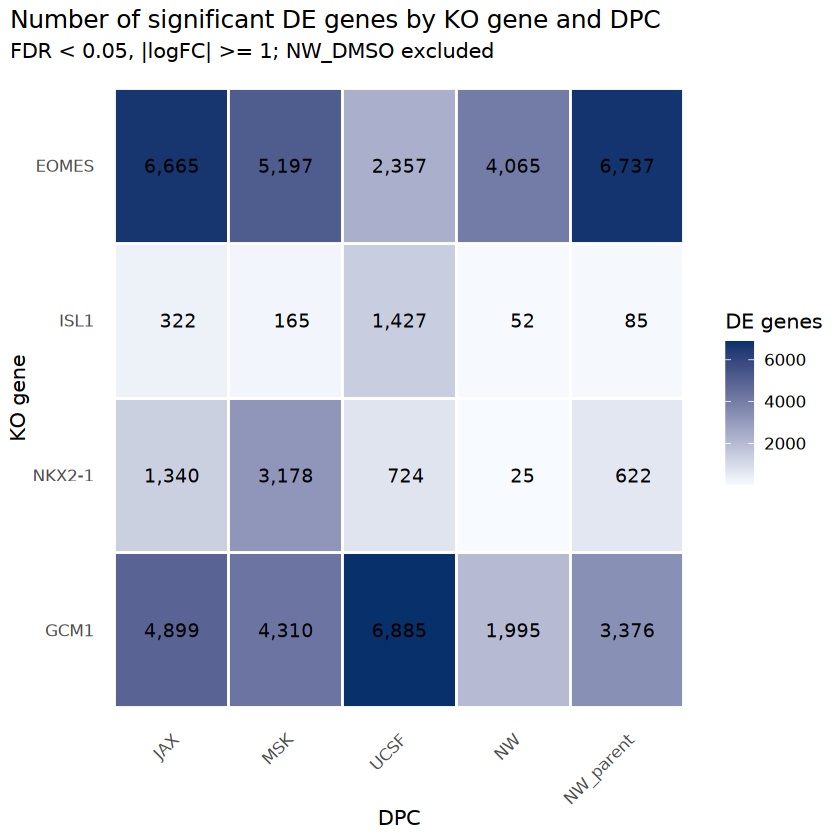

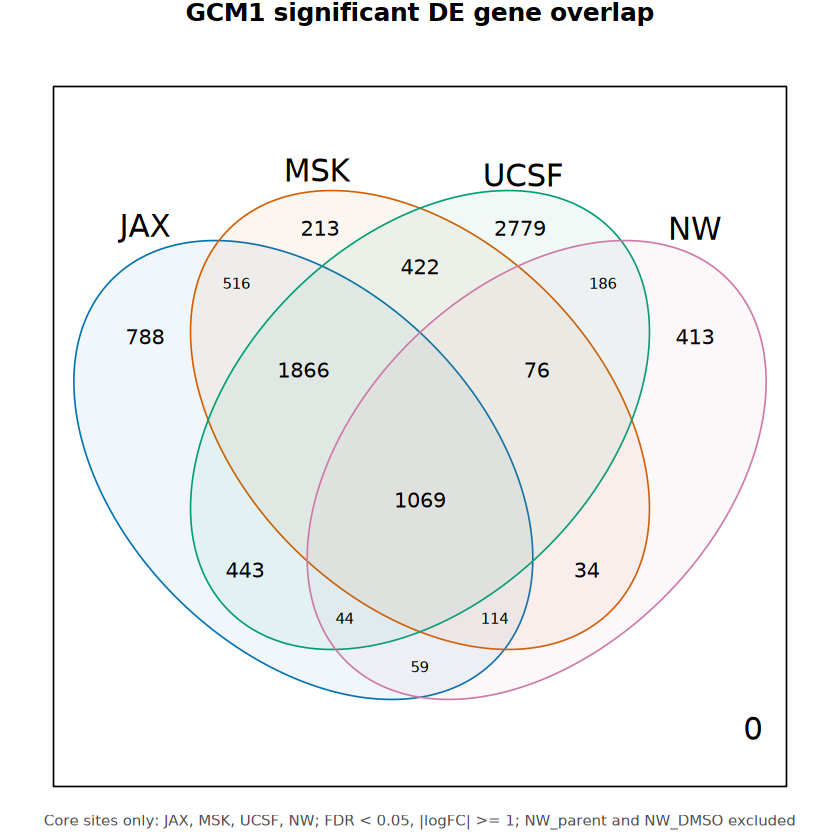

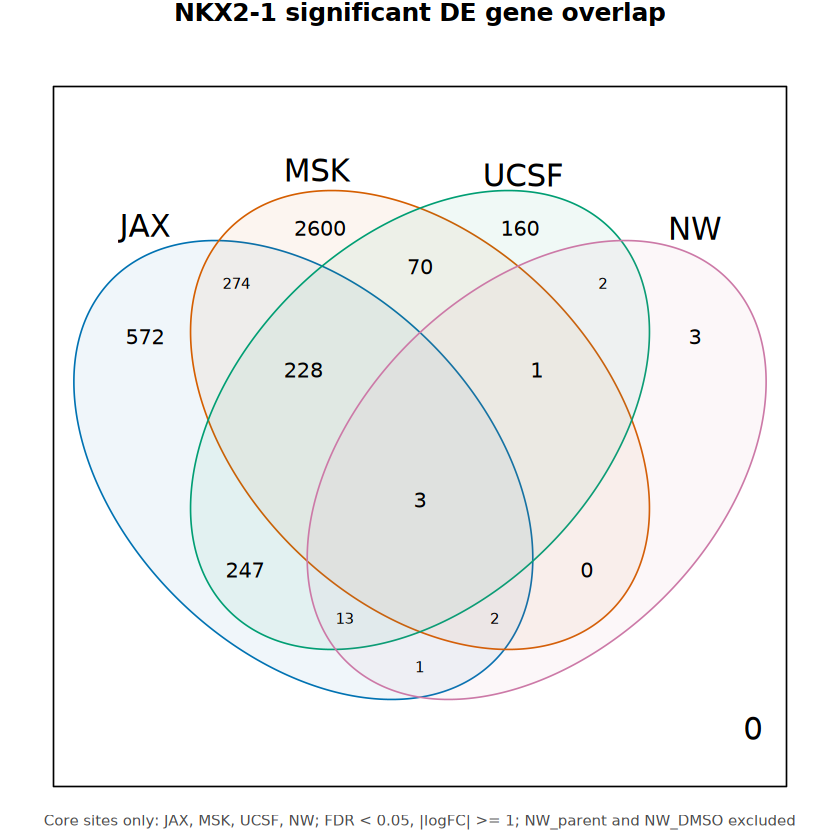

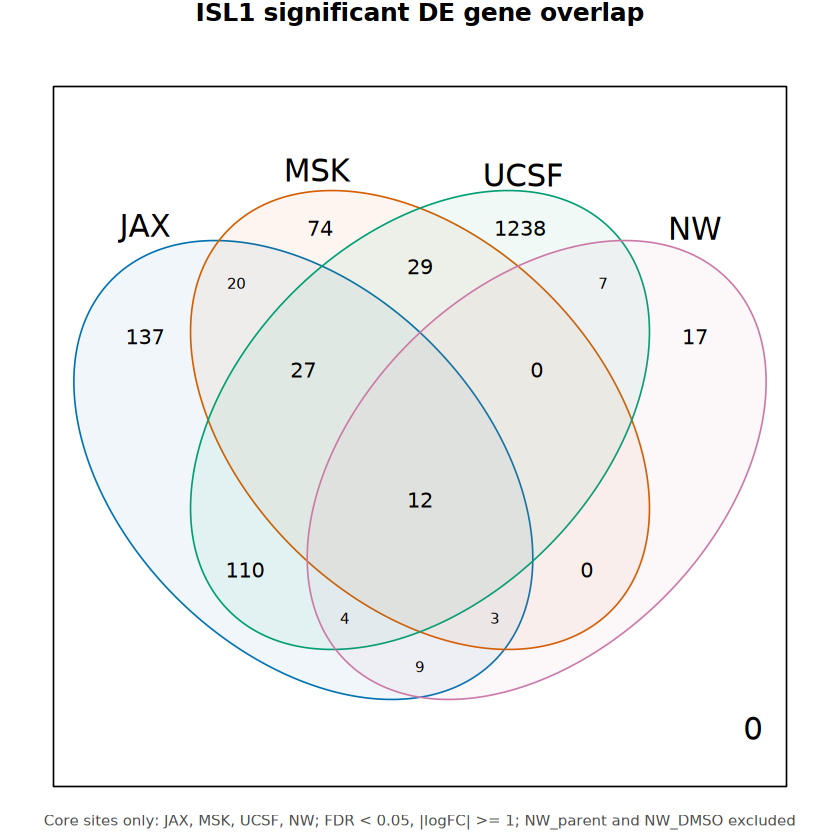

target_gene,figure,n_union,n_all_four_sites,n_JAX,n_MSK,n_UCSF,n_NW
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>
GCM1,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/DE_gene_overlap_venn/GCM1_DE_gene_overlap_core_sites_venn.png,9022,1069,4899,4310,6885,1995
NKX2-1,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/DE_gene_overlap_venn/NKX2_1_DE_gene_overlap_core_sites_venn.png,4176,3,1340,3178,724,25
ISL1,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/DE_gene_overlap_venn/ISL1_DE_gene_overlap_core_sites_venn.png,1687,12,322,165,1427,52
EOMES,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/DE_gene_overlap_venn/EOMES_DE_gene_overlap_core_sites_venn.png,9105,696,6665,5197,2357,4065


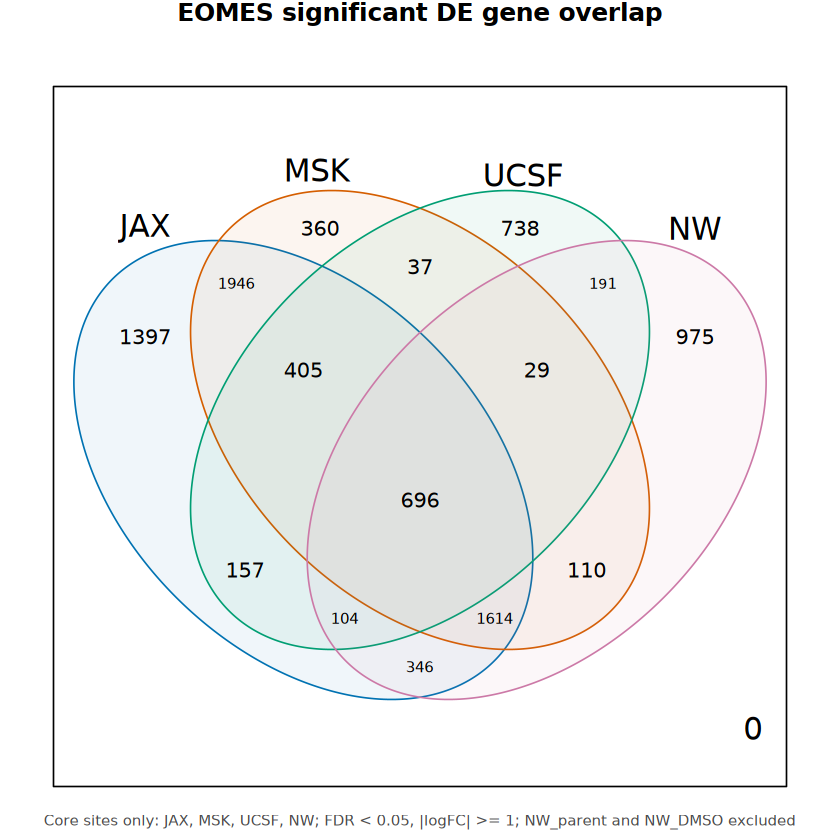

In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(ggplot2)
  library(limma)
  library(purrr)
  library(stringr)
  library(tibble)
  library(tidyr)
})

if (!exists("target_genes")) {
  target_genes <- c("GCM1", "NKX2-1", "ISL1", "EOMES")
}
if (!exists("core_institutions")) {
  core_institutions <- c("JAX", "MSK", "UCSF", "NW")
}
if (!exists("cohort_order")) {
  cohort_order <- c(core_institutions, "NW_parent", "NW_DMSO")
}
if (!exists("fdr_cutoff")) {
  fdr_cutoff <- 0.05
}
if (!exists("logfc_cutoff")) {
  logfc_cutoff <- 1
}
if (!exists("personal_path")) {
  personal_path <- Sys.getenv("MORPHIC_PERSONAL_PATH", unset = "/fh/working/sun_w/sshen/MorPhiC")
}
if (!exists("publication_dir")) {
  publication_dir <- file.path(personal_path, "publication")
}
if (!exists("figure_dir")) {
  figure_dir <- file.path(publication_dir, "DE_summary_ipynb")
}

stopifnot(dir.exists(publication_dir))
dir.create(figure_dir, recursive = TRUE, showWarnings = FALSE)

venn_cohorts <- core_institutions
heatmap_cohorts <- c(venn_cohorts, "NW_parent")
venn_figure_dir <- file.path(figure_dir, "DE_gene_overlap_venn")
dir.create(venn_figure_dir, recursive = TRUE, showWarnings = FALSE)

if (!exists("de_results")) {
  venn_de_file_paths <- list.files(
    publication_dir,
    pattern = "_DE_.*[.]csv$",
    full.names = TRUE
  )
  
  venn_de_file_index <- tibble(file = venn_de_file_paths) %>%
    mutate(
      file_name = basename(file),
      stem = tools::file_path_sans_ext(file_name),
      target_gene = sub("_DE_.*$", "", stem),
      cohort = sub("^.*_DE_", "", stem),
      dataset_id = paste(target_gene, cohort, sep = "_DE_")
    ) %>%
    filter(target_gene %in% target_genes) %>%
    arrange(
      factor(target_gene, levels = target_genes),
      factor(cohort, levels = cohort_order),
      cohort
    )
  
  expected_venn_core <- tidyr::expand_grid(
    target_gene = target_genes,
    cohort = venn_cohorts
  )
  missing_venn_files <- anti_join(
    expected_venn_core,
    venn_de_file_index %>% distinct(target_gene, cohort),
    by = c("target_gene", "cohort")
  )
  if (nrow(missing_venn_files) > 0) {
    stop(
      "Missing core DE CSV files: ",
      paste(paste(missing_venn_files$target_gene, missing_venn_files$cohort, sep = ":"), collapse = ", ")
    )
  }
  
  read_de_table_for_venn <- function(file, target_gene, cohort) {
    dt <- data.table::fread(file, data.table = FALSE)
    expected_cols <- c("logFC", "AveExpr", "t", "P.Value", "adj.P.Val", "B")
    
    if (!"gene_symbol" %in% names(dt)) {
      if ("V1" %in% names(dt)) {
        names(dt)[names(dt) == "V1"] <- "gene_symbol"
      } else if (ncol(dt) == length(expected_cols) + 1 && !(names(dt)[1] %in% expected_cols)) {
        names(dt)[1] <- "gene_symbol"
      } else {
        stop("Could not identify gene symbol column in ", file)
      }
    }
    
    missing_cols <- setdiff(c("gene_symbol", expected_cols), names(dt))
    if (length(missing_cols) > 0) {
      stop("Missing columns in ", file, ": ", paste(missing_cols, collapse = ", "))
    }
    
    dt %>%
      transmute(
        target_gene = target_gene,
        cohort = cohort,
        dataset_id = paste(target_gene, cohort, sep = "_DE_"),
        gene_symbol = as.character(gene_symbol),
        logFC = as.numeric(logFC),
        adj.P.Val = as.numeric(adj.P.Val),
        is_significant = adj.P.Val < fdr_cutoff & abs(logFC) >= logfc_cutoff
      )
  }
  
  de_results <- pmap_dfr(
    venn_de_file_index %>% select(file, target_gene, cohort),
    read_de_table_for_venn
  ) %>%
    mutate(
      target_gene = factor(target_gene, levels = target_genes),
      cohort = factor(cohort, levels = unique(c(cohort_order, sort(unique(as.character(cohort))))), ordered = TRUE)
    )
}

missing_venn_cohorts <- setdiff(venn_cohorts, as.character(unique(de_results$cohort)))
if (length(missing_venn_cohorts) > 0) {
  stop("Missing DE results for core cohorts: ", paste(missing_venn_cohorts, collapse = ", "))
}

venn_safe_name <- function(x) {
  str_replace_all(x, "[^A-Za-z0-9]+", "_") %>% str_replace_all("(^_|_$)", "")
}

make_core_site_de_membership <- function(gene1) {
  d <- de_results %>%
    mutate(
      target_gene = as.character(target_gene),
      cohort = as.character(cohort),
      gene_symbol = str_trim(gene_symbol)
    ) %>%
    filter(
      target_gene == gene1,
      cohort %in% venn_cohorts,
      is_significant,
      !is.na(gene_symbol),
      gene_symbol != ""
    ) %>%
    distinct(gene_symbol, cohort) %>%
    mutate(is_de = TRUE) %>%
    pivot_wider(
      names_from = cohort,
      values_from = is_de,
      values_fill = list(is_de = FALSE)
    )
  
  for (cohort1 in setdiff(venn_cohorts, names(d))) {
    d[[cohort1]] <- logical(nrow(d))
  }
  
  d %>%
    select(gene_symbol, all_of(venn_cohorts)) %>%
    arrange(gene_symbol)
}

core_site_de_membership <- map_dfr(target_genes, function(gene1) {
  make_core_site_de_membership(gene1) %>%
    mutate(target_gene = gene1, .before = gene_symbol)
})

core_site_membership_file <- file.path(venn_figure_dir, "DE_gene_overlap_core_site_membership.tsv")
data.table::fwrite(core_site_de_membership, core_site_membership_file, sep = "	")

core_site_de_counts <- de_results %>%
  mutate(
    target_gene = as.character(target_gene),
    cohort = as.character(cohort),
    gene_symbol = str_trim(gene_symbol)
  ) %>%
  filter(
    target_gene %in% target_genes,
    cohort %in% heatmap_cohorts,
    !is.na(gene_symbol),
    gene_symbol != ""
  ) %>%
  group_by(target_gene, cohort) %>%
  summarise(
    n_tested_genes = n_distinct(gene_symbol),
    n_de_genes = n_distinct(gene_symbol[is_significant]),
    .groups = "drop"
  ) %>%
  complete(
    target_gene = target_genes,
    cohort = heatmap_cohorts,
    fill = list(n_tested_genes = 0L, n_de_genes = 0L)
  ) %>%
  mutate(
    target_gene = factor(target_gene, levels = target_genes),
    cohort = factor(cohort, levels = heatmap_cohorts, ordered = TRUE)
  ) %>%
  arrange(target_gene, cohort)

core_site_de_counts_file <- file.path(venn_figure_dir, "DE_gene_counts_by_KO_and_DPC.tsv")
data.table::fwrite(core_site_de_counts, core_site_de_counts_file, sep = "	")

core_site_de_count_heatmap <- ggplot(core_site_de_counts, aes(x = cohort, y = target_gene, fill = n_de_genes)) +
  geom_tile(color = "white", linewidth = 0.6) +
  geom_text(aes(label = format(n_de_genes, big.mark = ",", scientific = FALSE)), size = 4) +
  scale_fill_gradient(low = "#F7FBFF", high = "#08306B") +
  labs(
    x = "DPC",
    y = "KO gene",
    fill = "DE genes",
    title = "Number of significant DE genes by KO gene and DPC",
    subtitle = paste0("FDR < ", fdr_cutoff, ", |logFC| >= ", logfc_cutoff, "; NW_DMSO excluded")
  ) +
  theme_minimal(base_size = 12) +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title.position = "plot"
  )

core_site_de_count_heatmap_file <- file.path(venn_figure_dir, "DE_gene_counts_by_KO_and_DPC_heatmap.png")
ggsave(
  filename = core_site_de_count_heatmap_file,
  plot = core_site_de_count_heatmap,
  width = 7,
  height = 4.5,
  device = "png",
  dpi = 300,
  bg = "white"
)

core_site_de_counts
print(core_site_de_count_heatmap)

make_core_site_venn_counts <- function(gene1) {
  membership_mat <- core_site_de_membership %>%
    filter(target_gene == gene1) %>%
    select(all_of(venn_cohorts)) %>%
    as.matrix()
  
  if (nrow(membership_mat) == 0) {
    membership_mat <- matrix(
      FALSE,
      nrow = 0,
      ncol = length(venn_cohorts),
      dimnames = list(NULL, venn_cohorts)
    )
  }
  
  storage.mode(membership_mat) <- "logical"
  limma::vennCounts(membership_mat)
}

draw_core_site_de_venn <- function(gene1) {
  venn_counts <- make_core_site_venn_counts(gene1)
  title_text <- paste0(gene1, " significant DE gene overlap")
  note_text <- paste0(
    "Core sites only: ", paste(venn_cohorts, collapse = ", "),
    "; FDR < ", fdr_cutoff,
    ", |logFC| >= ", logfc_cutoff,
    "; NW_parent and NW_DMSO excluded"
  )
  
  old_par <- par(mar = c(1.5, 1.2, 4.0, 1.2))
  on.exit(par(old_par), add = TRUE)
  limma::vennDiagram(
    venn_counts,
    names = venn_cohorts,
    circle.col = c("#0072B2", "#D55E00", "#009E73", "#CC79A7"),
    main = title_text
  )
  mtext(note_text, side = 1, line = 0, cex = 0.72, col = "grey30")
  invisible(venn_counts)
}

save_core_site_de_venn <- function(gene1, out_file) {
  grDevices::png(
    filename = out_file,
    width = 2200,
    height = 2200,
    res = 300,
    bg = "transparent"
  )
  tryCatch(
    draw_core_site_de_venn(gene1),
    finally = grDevices::dev.off()
  )
  invisible(out_file)
}

summarise_core_site_de_overlap <- function(gene1, out_file) {
  d <- core_site_de_membership %>% filter(target_gene == gene1)
  site_counts <- d %>%
    summarise(across(all_of(venn_cohorts), ~ sum(.x, na.rm = TRUE))) %>%
    rename_with(~ paste0("n_", .x))
  
  tibble(
    target_gene = gene1,
    figure = out_file,
    n_union = nrow(d),
    n_all_four_sites = sum(rowSums(as.matrix(d[, venn_cohorts])) == length(venn_cohorts))
  ) %>%
    bind_cols(site_counts)
}

if (exists("set_notebook_plot_size")) {
  set_notebook_plot_size(width = 7.5, height = 7.5, res = 140, pointsize = 12)
}

venn_index <- map_dfr(target_genes, function(gene1) {
  out_file <- file.path(
    venn_figure_dir,
    paste0(venn_safe_name(gene1), "_DE_gene_overlap_core_sites_venn.png")
  )
  save_core_site_de_venn(gene1, out_file)
  draw_core_site_de_venn(gene1)
  summarise_core_site_de_overlap(gene1, out_file)
})

if (exists("set_notebook_plot_size")) {
  set_notebook_plot_size()
}

data.table::fwrite(venn_index, file.path(venn_figure_dir, "DE_gene_overlap_core_site_venn_index.tsv"), sep = "	")
venn_index